# Imports and Data Setup

In [1]:
%load_ext autoreload
%autoreload 2

from ml.surrogate import SurrogateInversion, train_surrogate, Surrogate
from simulation.make_dataset import make_dataset
from simulation.simulator import *
from constants import *

import torch as t
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.patches as patches
from p_tqdm import p_map
from typing import Optional, Tuple
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import bootstrap, wilcoxon, mannwhitneyu
from copy import deepcopy

plt.rcParams.update({"font.size": 11, "figure.dpi": 200})
from scipy.ndimage import label, binary_closing, binary_opening, zoom, gaussian_filter1d


from matplotlib.lines import Line2D

/u/mgalexan/NPSurr/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Fixed values for plotting
phys = PhysicsConstants()
params = SimulationParameters()
dataset = DatasetParameters(filename= "ml_fig_dataset.npz")


In [3]:
model = t.load(f"{ROOT}/data/cin_model.pt", weights_only=False)
d_vals = np.linspace(20, 80, 25) * 1e-9
k_rel_vals = np.logspace(-6, -2, 25)
inv = SurrogateInversion(model, InversionParameters(), phys, params)

phys_const = PhysicsConstants()
dataset_params_const = DatasetParameters(
    save=False,
    d_val_m=np.array([phys_const.d_val_m]),
    k_rel= np.array([phys_const.k_rel])
)
data_const = make_dataset(phys_const, params, dataset_params_const)
CI = data_const["CI"][0,0]
x = np.linspace(0, 1, CI.shape[1])
mins = CI.min(axis=1, keepdims=True) + 1e-10
maxs = CI.max(axis=1, keepdims=True) + 1e-10
f = np.log(mins) + (np.log(maxs) - np.log(mins)) * x
CI_new = np.exp(f)
data_const["CI"] = CI_new




d_val_m:   0%|          | 0/1 [00:00<?, ?it/s]

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  1.74it/s]


In [4]:
def plot_surrogate_landscape_grid(
        L_surrs: list[ np.ndarray ],
        L_pdes: list[ np.ndarray ],
        d_grid: np.ndarray,
        k_rel_grid: np.ndarray,
        pred_points: list[tuple[float, float]],
        true_points: Optional[list[tuple[float, float]]] = None,
        fig: Optional[plt.Figure] = None,
        axes: Optional[np.ndarray] = None,
        surr_norm: Optional[colors.Normalize] = None,
        pde_norm: Optional[colors.Normalize] = None,
    ) -> tuple[plt.Figure, np.ndarray]:

        n = len(pred_points)
        if true_points is None:
            true_points = n * [None]
        if fig is None or axes is None:
                # Use gridspec_kw to increase horizontal spacing between columns and
                # disable constrained_layout so gridspec spacing takes effect.
                fig, axes = plt.subplots(2, n, figsize=(3.0 * n, 6.0), sharex=True, sharey=True, gridspec_kw={'wspace': 0.25, 'hspace': 0.15}, constrained_layout=False)

        if axes.ndim == 1:
            axes = axes.reshape(2, -1)

        # Convert surrogate log-loss back to raw values and clean arrays
        surr_clean_list = [np.where(np.isfinite(L) & (np.exp(L) >= 0), np.exp(L), np.nan) for L in L_surrs]
        pde_clean_list = [np.where(np.isfinite(L) & (L >= 0), L, np.nan) for L in L_pdes]

        # Compute separate normalization for surrogate and PDE rows
        surr_all = np.concatenate([arr.ravel() for arr in surr_clean_list])
        surr_finite = surr_all[np.isfinite(surr_all)]
        if surr_norm is None:
            if surr_finite.size > 0:
                surr_norm = colors.LogNorm(vmin=surr_finite.min(), vmax=surr_finite.max())
            else:
                surr_norm = colors.Normalize(vmin=0.0, vmax=1.0)

        pde_all = np.concatenate([arr.ravel() for arr in pde_clean_list])
        pde_finite = pde_all[np.isfinite(pde_all)]
        if pde_norm is None:
            if surr_finite.size > 0:
                pde_norm = colors.LogNorm(vmin=surr_finite.min(), vmax=surr_finite.max())
            else:
                pde_norm = colors.Normalize(vmin=0.0, vmax=1.0)

        x = d_grid * 1e9
        y = k_rel_grid

        # Keep track of last pcm handles (one per row) to build colorbars
        last_pcm_surr = None
        last_pcm_pde = None

        for col, (ax_surf, ax_pde, L_surf_clean, L_pde_clean, true_pt, pred_pt) in enumerate(zip(axes[0], axes[1], surr_clean_list, pde_clean_list, true_points, pred_points)):
            last_pcm_surr = ax_surf.pcolormesh(
                x,
                y,
                L_surf_clean.T,
                cmap="RdYlBu_r",
                shading="auto",
                norm=surr_norm,
            )
            ax_surf.contour(
                x,
                y,
                L_surf_clean.T,
                levels=18,
                colors="k",
                linewidths=0.4,
                alpha=0.35,
            )
            if true_pt:
                ax_surf.scatter(
                    true_pt[0] * 1e9,
                    true_pt[1],
                    c="cyan",
                    s=120,
                    marker="*",
                    edgecolors="k",
                    linewidths=0.8,
                    label="Data point",
                    zorder=6,
            )
            ax_surf.scatter(
                pred_pt[0] * 1e9,
                pred_pt[1],
                c="red",
                s=90,
                marker="x",
                linewidths=2.5,
                label="Estimated point",
                zorder=6,
            )
            if true_pt:
                ax_surf.set_title(rf"$d={true_pt[0]*1e9:.0f}\ \mathrm{{nm}}, \ k_{{rel}}={true_pt[1]:.1g}\ \mathrm{{1/s}}$" + "\nSurrogate", fontsize=8)
            ax_surf.grid(alpha=0.25)
            ax_surf.legend(fontsize=9, loc="upper right", frameon= True)

            last_pcm_pde = ax_pde.pcolormesh(
                x,
                y,
                L_pde_clean.T,
                cmap="RdYlBu_r",
                shading="auto",
                norm=pde_norm,
            )
            ax_pde.contour(
                x,
                y,
                L_pde_clean.T,
                levels=18,
                colors="k",
                linewidths=0.4,
                alpha=0.35,
            )
            if true_pt:
                ax_pde.scatter(
                    true_pt[0] * 1e9,
                    true_pt[1],
                    c="cyan",
                    s=120,
                    marker="*",
                    edgecolors="k",
                    linewidths=0.8,
                    label="Data point",
                    zorder=6,
                )
            ax_pde.scatter(
                pred_pt[0] * 1e9,
                pred_pt[1],
                c="red",
                s=90,
                marker="x",
                linewidths=2.5,
                label="Estimated point",
                zorder=6,
            )
            ax_pde.set_title("PDE", fontsize=8)
            ax_pde.grid(alpha=0.25)
            ax_pde.legend(fontsize=9, loc="upper right", frameon= True)

        for ax in axes[1, :]:
            ax.set_xlabel(r"$d$ (nm)")
        for ax in axes[:, 0]:
            ax.set_ylabel(r"$k_{\mathrm{rel}}$ (1/s)")
        for ax in axes.flatten():
            ax.set_yscale("log")

        fig.suptitle("Surrogate vs PDE loss landscape per evaluated point", fontsize=16, y=1.02)

        # Create compact colorbars adjacent to the last column of each row
        if last_pcm_surr is not None:
            divider = make_axes_locatable(axes[0, -1])
            cax_surr = divider.append_axes("right", size="3%", pad=0.1)
            cbar_surr = fig.colorbar(last_pcm_surr, cax=cax_surr)
            cbar_surr.set_label(r"$\mathcal{L}_{surr}$")
        if last_pcm_pde is not None:
            divider = make_axes_locatable(axes[1, -1])
            cax_pde = divider.append_axes("right", size="3%", pad=0.1)
            cbar_pde = fig.colorbar(last_pcm_pde, cax=cax_pde, norm=pde_norm)
            cbar_pde.set_label(r"$\mathcal{L}_{PDE}$")

        return fig, axes

def plot_just_surrogate(
        L_surrs: list[ np.ndarray ],
        d_grid: np.ndarray,
        k_rel_grid: np.ndarray,
        pred_points: list[tuple[float, float]],
        true_points: Optional[list[tuple[float, float]]] = None,
        fig: Optional[plt.Figure] = None,
        axes: Optional[np.ndarray] = None,
        surr_norm: Optional[colors.Normalize] = None,
    ) -> tuple[plt.Figure, np.ndarray]:
        n = len(pred_points)
        if true_points is None:
            true_points = n * [None]
        if fig is None or axes is None:
                # Use gridspec_kw to increase horizontal spacing between columns and
                # disable constrained_layout so gridspec spacing takes effect.
                fig, axes = plt.subplots(1, n, figsize=(3.0 * n, 3.0), sharex=True, sharey=True, gridspec_kw={'wspace': 0.25, 'hspace': 0.15}, constrained_layout=False)

        if axes.ndim == 1:
            axes = axes.reshape(1, -1)

        # Convert surrogate log-loss back to raw values and clean arrays
        surr_clean_list = [np.where(np.isfinite(L) & (np.exp(L) >= 0), np.exp(L), np.nan) for L in L_surrs]

        # Compute separate normalization for surrogate and PDE rows
        surr_all = np.concatenate([arr.ravel() for arr in surr_clean_list])
        surr_finite = surr_all[np.isfinite(surr_all)]
        if surr_norm is None:
            if surr_finite.size > 0:
                surr_norm = colors.LogNorm(vmin=surr_finite.min(), vmax=surr_finite.max())
            else:
                surr_norm = colors.Normalize(vmin=0.0, vmax=1.0)


        x = d_grid * 1e9
        y = k_rel_grid

        # Keep track of last pcm handles (one per row) to build colorbars
        last_pcm_surr = None

        for col, (ax_surf, L_surf_clean, true_pt, pred_pt) in enumerate(zip(axes[0], surr_clean_list, true_points, pred_points)):
            last_pcm_surr = ax_surf.pcolormesh(
                x,
                y,
                L_surf_clean.T,
                cmap="RdYlBu_r",
                shading="auto",
                norm="log",
            )
            ax_surf.contour(
                x,
                y,
                L_surf_clean.T,
                levels=18,
                colors="k",
                linewidths=0.4,
                alpha=0.35,
            )
            if true_pt:
                ax_surf.scatter(
                    true_pt[0] * 1e9,
                    true_pt[1],
                    c="cyan",
                    s=120,
                    marker="*",
                    edgecolors="k",
                    linewidths=0.8,
                    label="Data point",
                    zorder=6,
            )
            ax_surf.scatter(
                pred_pt[0] * 1e9,
                pred_pt[1],
                c="red",
                s=90,
                marker="x",
                linewidths=2.5,
                label="Estimated point",
                zorder=6,
            )
            if true_pt:
                ax_surf.set_title(rf"$d={true_pt[0]*1e9:.0f}\ \mathrm{{nm}},\ k_{{rel}}={true_pt[1]:.1g}\ \mathrm{{1/s}}$" + "\nSurrogate")
            ax_surf.grid(alpha=0.25)
            ax_surf.legend(fontsize=9, loc="upper right", frameon= True)


        for ax in axes[0, :]:
            ax.set_xlabel(r"$d$ (nm)")
        for ax in axes[:, 0]:
            ax.set_ylabel(r"$k_{\mathrm{rel}}$ (1/s)")
        for ax in axes.flatten():
            ax.set_yscale("log")

        fig.suptitle("Surrogate vs PDE loss landscape per evaluated point", fontsize=16, y=1.02)

        # Create compact colorbars adjacent to the last column of each row
        if last_pcm_surr is not None:
            divider = make_axes_locatable(axes[0, -1])
            cax_surr = divider.append_axes("right", size="3%", pad=0.1)
            cbar_surr = fig.colorbar(last_pcm_surr, cax=cax_surr)
            cbar_surr.set_label(r"$\mathcal{L}_{surr}$")

        return fig, axes


# Training and Validation Curves

In [5]:
history = np.load(f"/{ROOT}/data/trn_val_hist.npz")
trn = history["trn"]
val = history["val"]

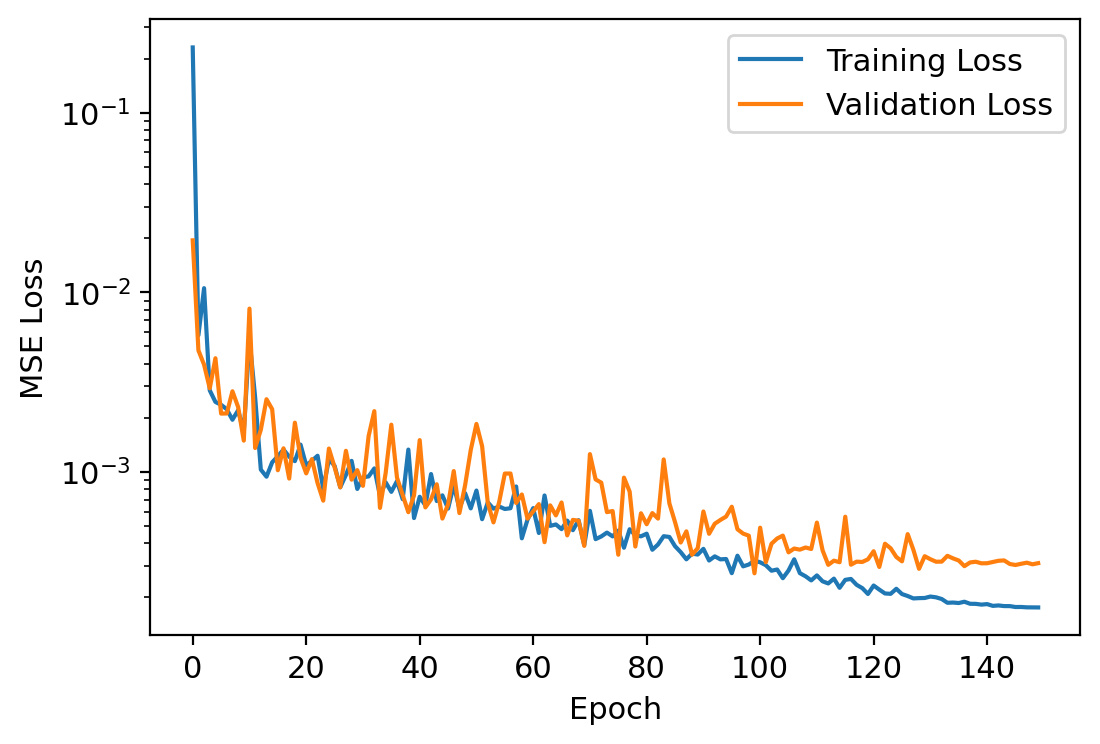

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(trn, label="Training Loss")
ax.semilogy(val, label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()

# Retrieval of a Physical Profile

In [7]:
point_d_vals = [
    50e-9,
    75e-9,
    25e-9
]
point_k_rel_vals = [
    1e-5,
    1e-4,
    1e-3
]
points = list(zip(point_d_vals, point_k_rel_vals))

def single_point_dataset(d_val_m, k_rel):
    phys = PhysicsConstants(d_val_m= d_val_m, k_rel = k_rel)
    obs_dataset_params = DatasetParameters(    
        d_val_m= np.array([d_val_m]),
        k_rel= np.array([k_rel]),
        save= False
    )
    obs_dataset = make_dataset(phys, params, obs_dataset_params)
    obs_dataset["CN"] = obs_dataset["CN"][0,0]; obs_dataset["CF"] = obs_dataset["CF"][0,0]; obs_dataset["CI"] = obs_dataset["CI"][0,0]
    return obs_dataset

surr_maker = lambda d_val_m, k_rel: inv.loss_surface(single_point_dataset(d_val_m, k_rel), d_vals, k_rel_vals)
pde_maker = lambda d_val_m, k_rel: inv.pde_misfit_surface(single_point_dataset(d_val_m, k_rel), d_vals, k_rel_vals)

L_surrs = p_map(surr_maker, point_d_vals, point_k_rel_vals)
L_pdes = p_map(pde_maker, point_d_vals, point_k_rel_vals)

100%|██████████| 3/3 [03:51<00:00, 77.09s/it] 


d_val_m: 100%|██████████| 1/1 [00:00<00:00,  1.83it/s]


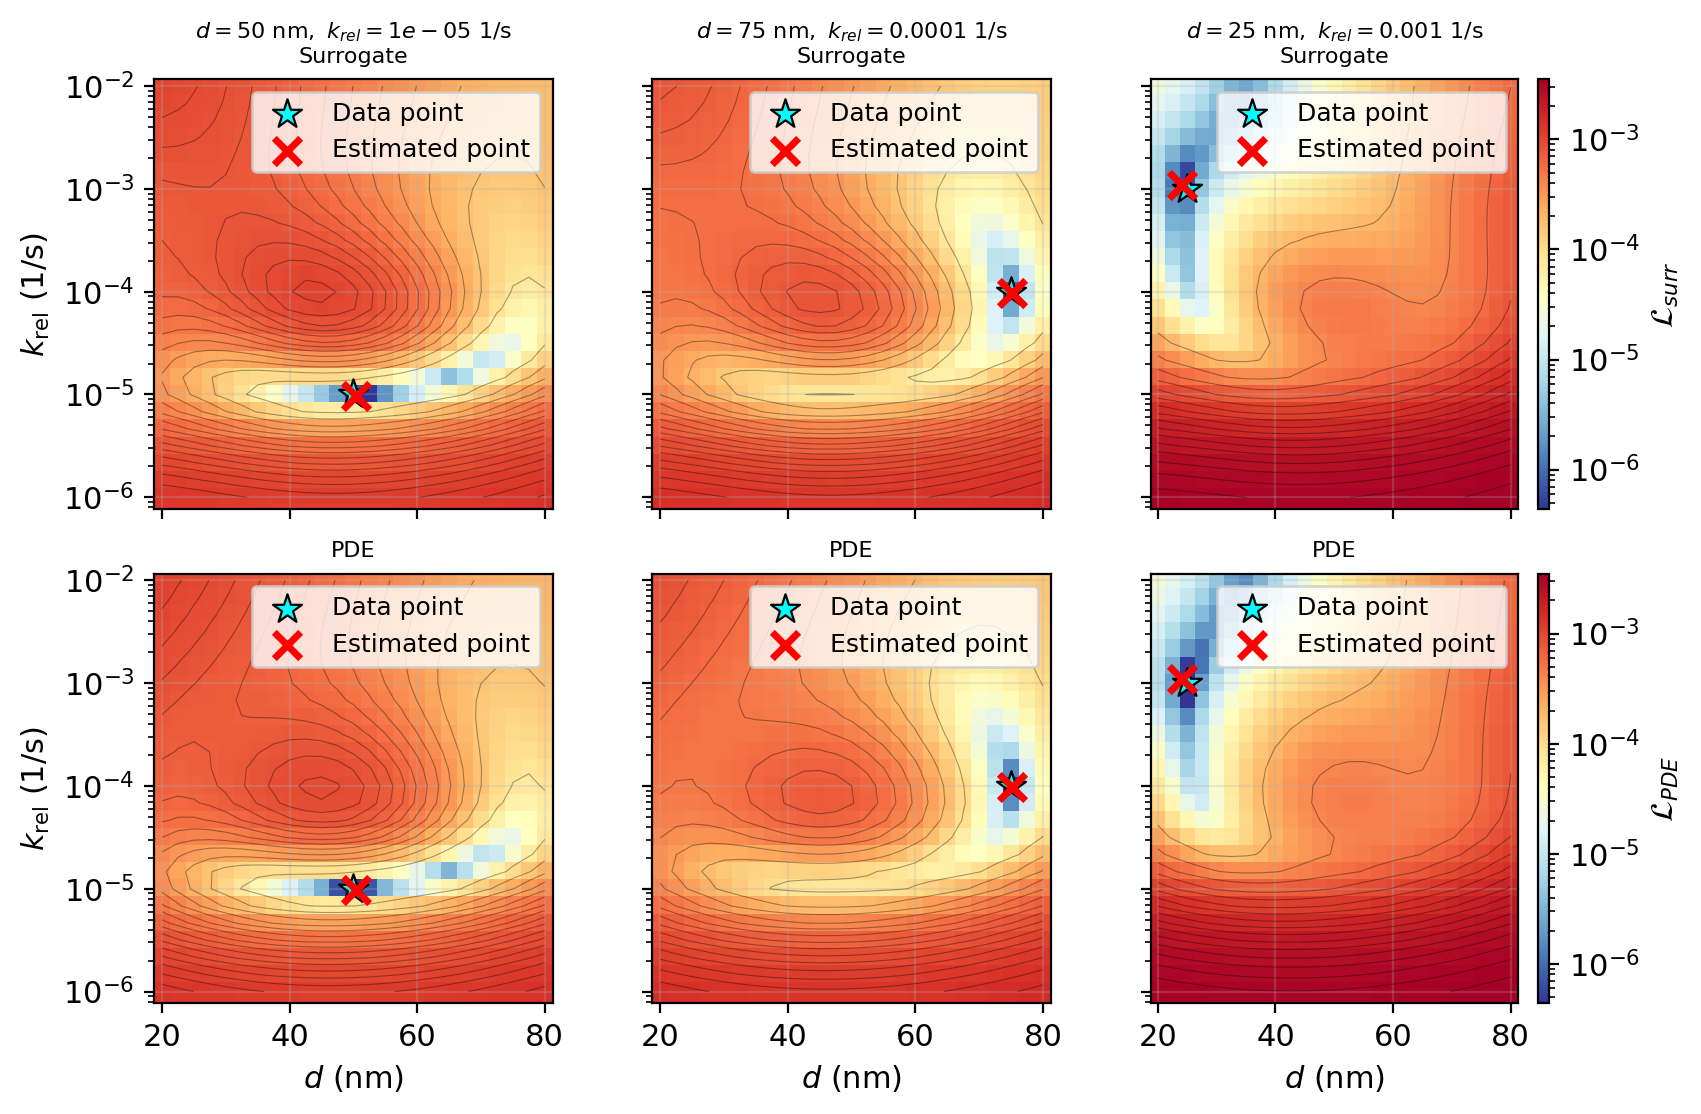

In [8]:
pred_points = []
for d_val_m, k_rel in points:
    phys = PhysicsConstants(d_val_m=d_val_m, k_rel= k_rel)
    obs_dataset_params = DatasetParameters(
        d_val_m=np.array([d_val_m]),
        k_rel=np.array([k_rel]),
        save=False,
    )
    obs_dataset = make_dataset(phys, params, obs_dataset_params)
    obs_dataset["CN"] = obs_dataset["CN"][0, 0]
    obs_dataset["CF"] = obs_dataset["CF"][0, 0]
    obs_dataset["CI"] = obs_dataset["CI"][0, 0]
    result = inv.invert(obs_dataset)
    pred_points.append(tuple(result))

fig, axes = plot_surrogate_landscape_grid(
    L_surrs,
    L_pdes,
    d_vals,
    k_rel_vals,
    pred_points,
    points,
)
fig._suptitle.remove()
plt.show()

# Retrieval of a Nonphysical Profile

In [9]:
const_res = inv.invert(data_const)
L_surr = inv.loss_surface(data_const, d_vals, k_rel_vals)
L_pde = inv.pde_misfit_surface(data_const, d_vals, k_rel_vals)
data_res = DatasetParameters(
    save=False,
    d_val_m= const_res[:1],
    k_rel= const_res[1:]
)
retrieved_data = make_dataset(phys_const, params, data_res)
retrieved_data["CI"] = retrieved_data["CI"][0,0]


d_val_m: 100%|██████████| 1/1 [00:00<00:00,  2.28it/s]


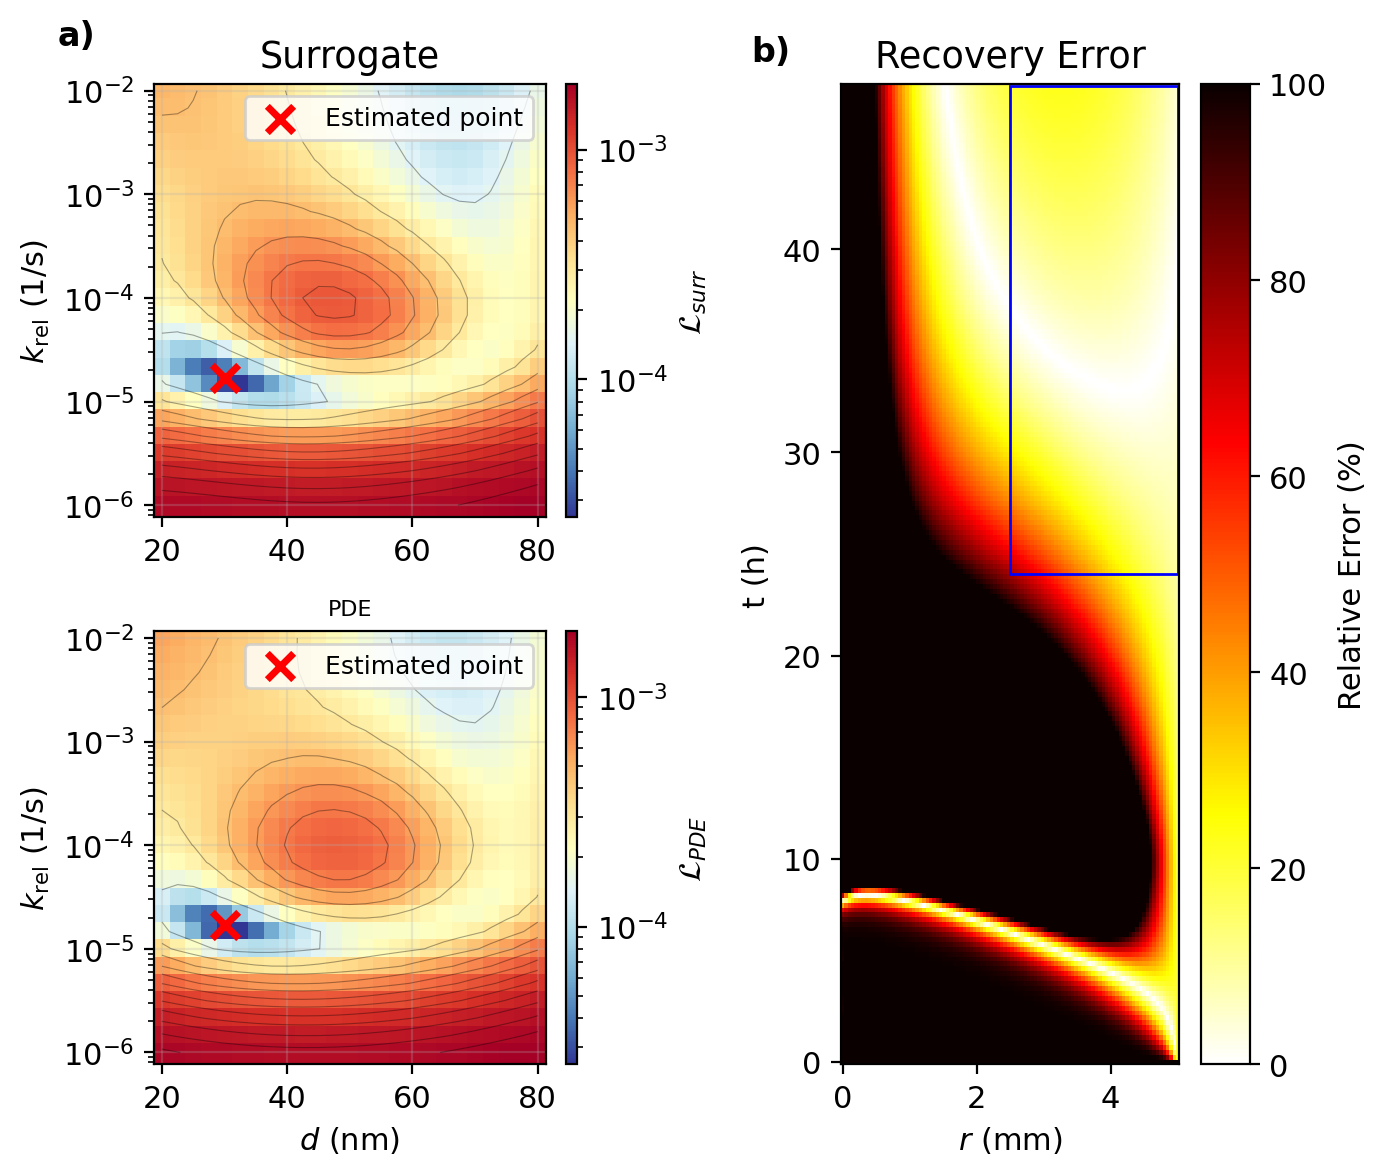

In [14]:
shape = [["C", "E"], ["D", "E"]]
fig, axd = plt.subplot_mosaic(shape, figsize= (7, 6))

plot_surrogate_landscape_grid(
    [L_surr],
    [L_pde],
    d_vals,
    k_rel_vals,
    [const_res],
    fig=fig,
    axes = np.array([axd["C"], axd["D"]])
)
axd["C"].set_title("Surrogate")

rel = np.abs(retrieved_data["CI"] - data_const["CI"]) * 100 / data_const["CI"]
rel.astype(np.int32)

r_vals = retrieved_data["r"] * 1000
t_vals = retrieved_data["t_out"] / 3600

t_idx_1 = 50
t_val_1 = retrieved_data["t_out"][t_idx_1] / 3600
'''
axd["A"].semilogy(r_vals, retrieved_data["CI"][t_idx_1], linestyle="--", color= "orange", label="Retrieved")
axd["A"].semilogy(r_vals, data_const["CI"][t_idx_1], color= "blue", label= "Target")
axd["A"].set_title(f"Profile Comparison at t={t_val_1:.0f}h")
axd["A"].set_ylabel(r"$C_I$ (mol)")
axd["A"].legend()

t_idx_2 = 100
t_val_2 = retrieved_data["t_out"][t_idx_2] / 3600
axd["B"].semilogy(r_vals, retrieved_data["CI"][t_idx_2], linestyle="--", color= "orange", label= "Retrieved")
axd["B"].semilogy(r_vals, data_const["CI"][t_idx_2], color= "blue", label= "Target")
axd["B"].set_title(f"Profile Comparison at t={t_val_2:.0f}h")
axd["B"].set_ylabel(r"$C_I$ (mol)")
axd["B"].legend()
axd["B"].set_xlabel(r"$r$ (mm)")
'''
err_rect = patches.Rectangle((2.5, 24), 2.5, 24, linewidth=1, edgecolor='b', facecolor="none")

err = axd["E"].pcolormesh(r_vals, t_vals, rel, cmap="hot_r", vmax= 100, vmin= 0)
axd["E"].add_patch(err_rect)
axd["E"].set_xlabel(r"$r$ (mm)")
axd["E"].set_ylabel(r"t (h)")
axd["E"].set_title("Recovery Error")
cbar_err = fig.colorbar(err)
cbar_err.set_label("Relative Error (%)")
fig._suptitle.remove()
axd["C"].text(-0.15, 1.15, "a)", transform=axd["C"].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
axd["E"].text(-0.15, 1.05, "b)", transform=axd["E"].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

fig.tight_layout()

# Multiple ECM Optimization Experiment

In [5]:
sigma_d_vals = np.linspace(10e-9, 50e-9, 20)
d_opt_vals = np.linspace(20e-9, 80e-9, 20)
P0_vals = [1e-10, 1e-9, 1e-8]
d_pore_vals = [80e-9, 150e-9, 300e-9]
xi_ECM_vals = [25e-9, 60e-9, 120e-9]
ECM_options = ["Transport-Resistant", "Intermediate", "Transport-Permissive"]


sigma_d_ordered = []
d_opt_ordered = []
d_pore_ordered = []
phys_list = []
model_list = []
inv_list = []
labels = []

for d_opt in d_opt_vals:
    for sigma_d in sigma_d_vals:
        for i in range(len(d_pore_vals)):
            d_pore = d_pore_vals[i]
            xi_ECM = xi_ECM_vals[i]
            P0 = P0_vals[i]
            sigma_d_ordered.append(sigma_d)
            d_opt_ordered.append(d_opt)
            d_pore_ordered.append(d_pore)
            labels.append(f"d_opt={d_opt:.2g}\n sigma_d={sigma_d:.2g}\n {ECM_options[i]} Phenotype")
            phys_list.append(PhysicsConstants(P0= P0, d_pore=d_pore, xi_ECM=xi_ECM, d_opt=d_opt, sigma_d=sigma_d))
            model_list.append(t.load(f"{ROOT}/data/d_opt={d_opt:.2g}_sigma_d={sigma_d:.2g}_d_pore={d_pore:.2g}_model.pt", weights_only= False))
            inv_list.append(SurrogateInversion(model_list[-1], InversionParameters(), phys_list[-1], params))



In [ ]:
surr_maker = lambda i: i.loss_surface(data_const, d_vals, k_rel_vals, "CI")
pde_maker = lambda i : i.pde_misfit_surface(data_const, d_vals, k_rel_vals, "CI")
res_maker = lambda i : i.invert(data_const, "CI")

L_surr_list = p_map(surr_maker, inv_list)
L_pde_list = p_map(pde_maker, inv_list)
res_list = p_map(res_maker, inv_list)
d_res_list = [res[0] * 1e9 for res in res_list]
k_rel_res_list = [res[1] for res in res_list]

100%|██████████| 25/25 [02:01<00:00,  4.87s/it]

100%|██████████| 25/25 [02:02<00:00,  4.89s/it]

100%|██████████| 25/25 [02:07<00:00,  5.08s/it]

100%|██████████| 1200/1200 [01:04<00:00, 18.63it/s]


In [57]:
np.savez(f"/{ROOT}/data/loss_landscapes", L_pde = np.array(L_pde_list), L_surr = np.array(L_surr_list), d = np.array(d_res_list), k_rel = np.array(k_rel_res_list))

In [6]:
dataset = np.load(f"{ROOT}/data/loss_landscapes.npz")
L_surr_list = dataset["L_surr"]
L_pde_list = dataset["L_pde"]
d_res_list = dataset["d"]
k_rel_res_list = dataset["k_rel"]
res_list = list(zip(d_res_list / 1e9, k_rel_res_list))

In [19]:
L_surr_flat = [np.exp(L.flatten()) for L in L_surr_list]
L_pde_flat = [L.flatten() for L in L_pde_list]
corr_vals = np.array(p_map(np.corrcoef, L_surr_flat, L_pde_flat))
print(corr_vals.mean())
print(corr_vals.std())

100%|██████████| 1200/1200 [00:00<00:00, 1306.27it/s]


0.9972804251851907
0.00657791479215589


In [20]:
d_vals_dense = np.array(d_res_list[0::3])
d_vals_medium = np.array(d_res_list[1::3])
d_vals_loose = np.array(d_res_list[2::3])

k_vals_dense = np.array(k_rel_res_list[0::3])
k_vals_medium = np.array(k_rel_res_list[1::3])
k_vals_loose = np.array(k_rel_res_list[2::3])

In [21]:
diff_d_dense_medium = d_vals_dense - d_vals_medium
diff_d_medium_loose = d_vals_medium - d_vals_loose
diff_k_dense_medium = k_vals_dense - k_vals_medium
diff_k_medium_loose = k_vals_medium - k_vals_loose

res_d_dense_medium = bootstrap((diff_d_dense_medium,), np.mean, confidence_level=0.95, n_resamples=10000, method="BCa", random_state=42)
res_d_medium_loose = bootstrap((diff_d_medium_loose,), np.mean, confidence_level=0.95, n_resamples=10000, method="BCa", random_state=42)
res_k_dense_medium = bootstrap((diff_k_dense_medium,), np.mean, confidence_level=0.95, n_resamples=10000, method="BCa", random_state=42)
res_k_medium_loose = bootstrap((diff_k_medium_loose,), np.mean, confidence_level=0.95, n_resamples=10000, method="BCa", random_state=42)

stat_d_dense_medium, p_d_dense_medium = wilcoxon(d_vals_dense, d_vals_medium)
stat_d_medium_loose, p_d_medium_loose = wilcoxon(d_vals_medium, d_vals_loose)
stat_k_dense_medium, p_k_dense_medium = wilcoxon(k_vals_dense, k_vals_medium)
stat_k_medium_loose, p_k_medium_loose = wilcoxon(k_vals_medium, k_vals_loose)



print(rf"Difference in d from dense to medium: {diff_d_dense_medium.mean():.2f}, 95% C.I. ({res_d_dense_medium.confidence_interval.low:.2f}, {res_d_dense_medium.confidence_interval.high:.2f}), p={p_d_dense_medium:.3g}")
print(rf"Difference in d from medium to loose: {diff_d_medium_loose.mean():.2f}, 95% C.I. ({res_d_medium_loose.confidence_interval.low:.2f}, {res_d_medium_loose.confidence_interval.high:.2f}), p={p_d_medium_loose:.3g}")
print(rf"Difference in k from dense to medium: {diff_k_dense_medium.mean():.2g}, 95% C.I. ({res_k_dense_medium.confidence_interval.low:.2g}, {res_k_dense_medium.confidence_interval.high:.2g}), p={p_k_dense_medium:.3g}")
print(rf"Difference in k from medium to loose: {diff_k_medium_loose.mean():.2g}, 95% C.I. ({res_k_medium_loose.confidence_interval.low:.2g}, {res_k_medium_loose.confidence_interval.high:.2g}), p={p_k_medium_loose:.3g}")

Difference in d from dense to medium: -13.62, 95% C.I. (-15.11, -12.24), p=2.13e-55
Difference in d from medium to loose: -2.35, 95% C.I. (-3.05, -1.65), p=8.22e-15
Difference in k from dense to medium: 0.00014, 95% C.I. (7.4e-05, 0.00024), p=0.0366
Difference in k from medium to loose: -4.2e-05, 95% C.I. (-0.00014, -2.1e-05), p=3.45e-55


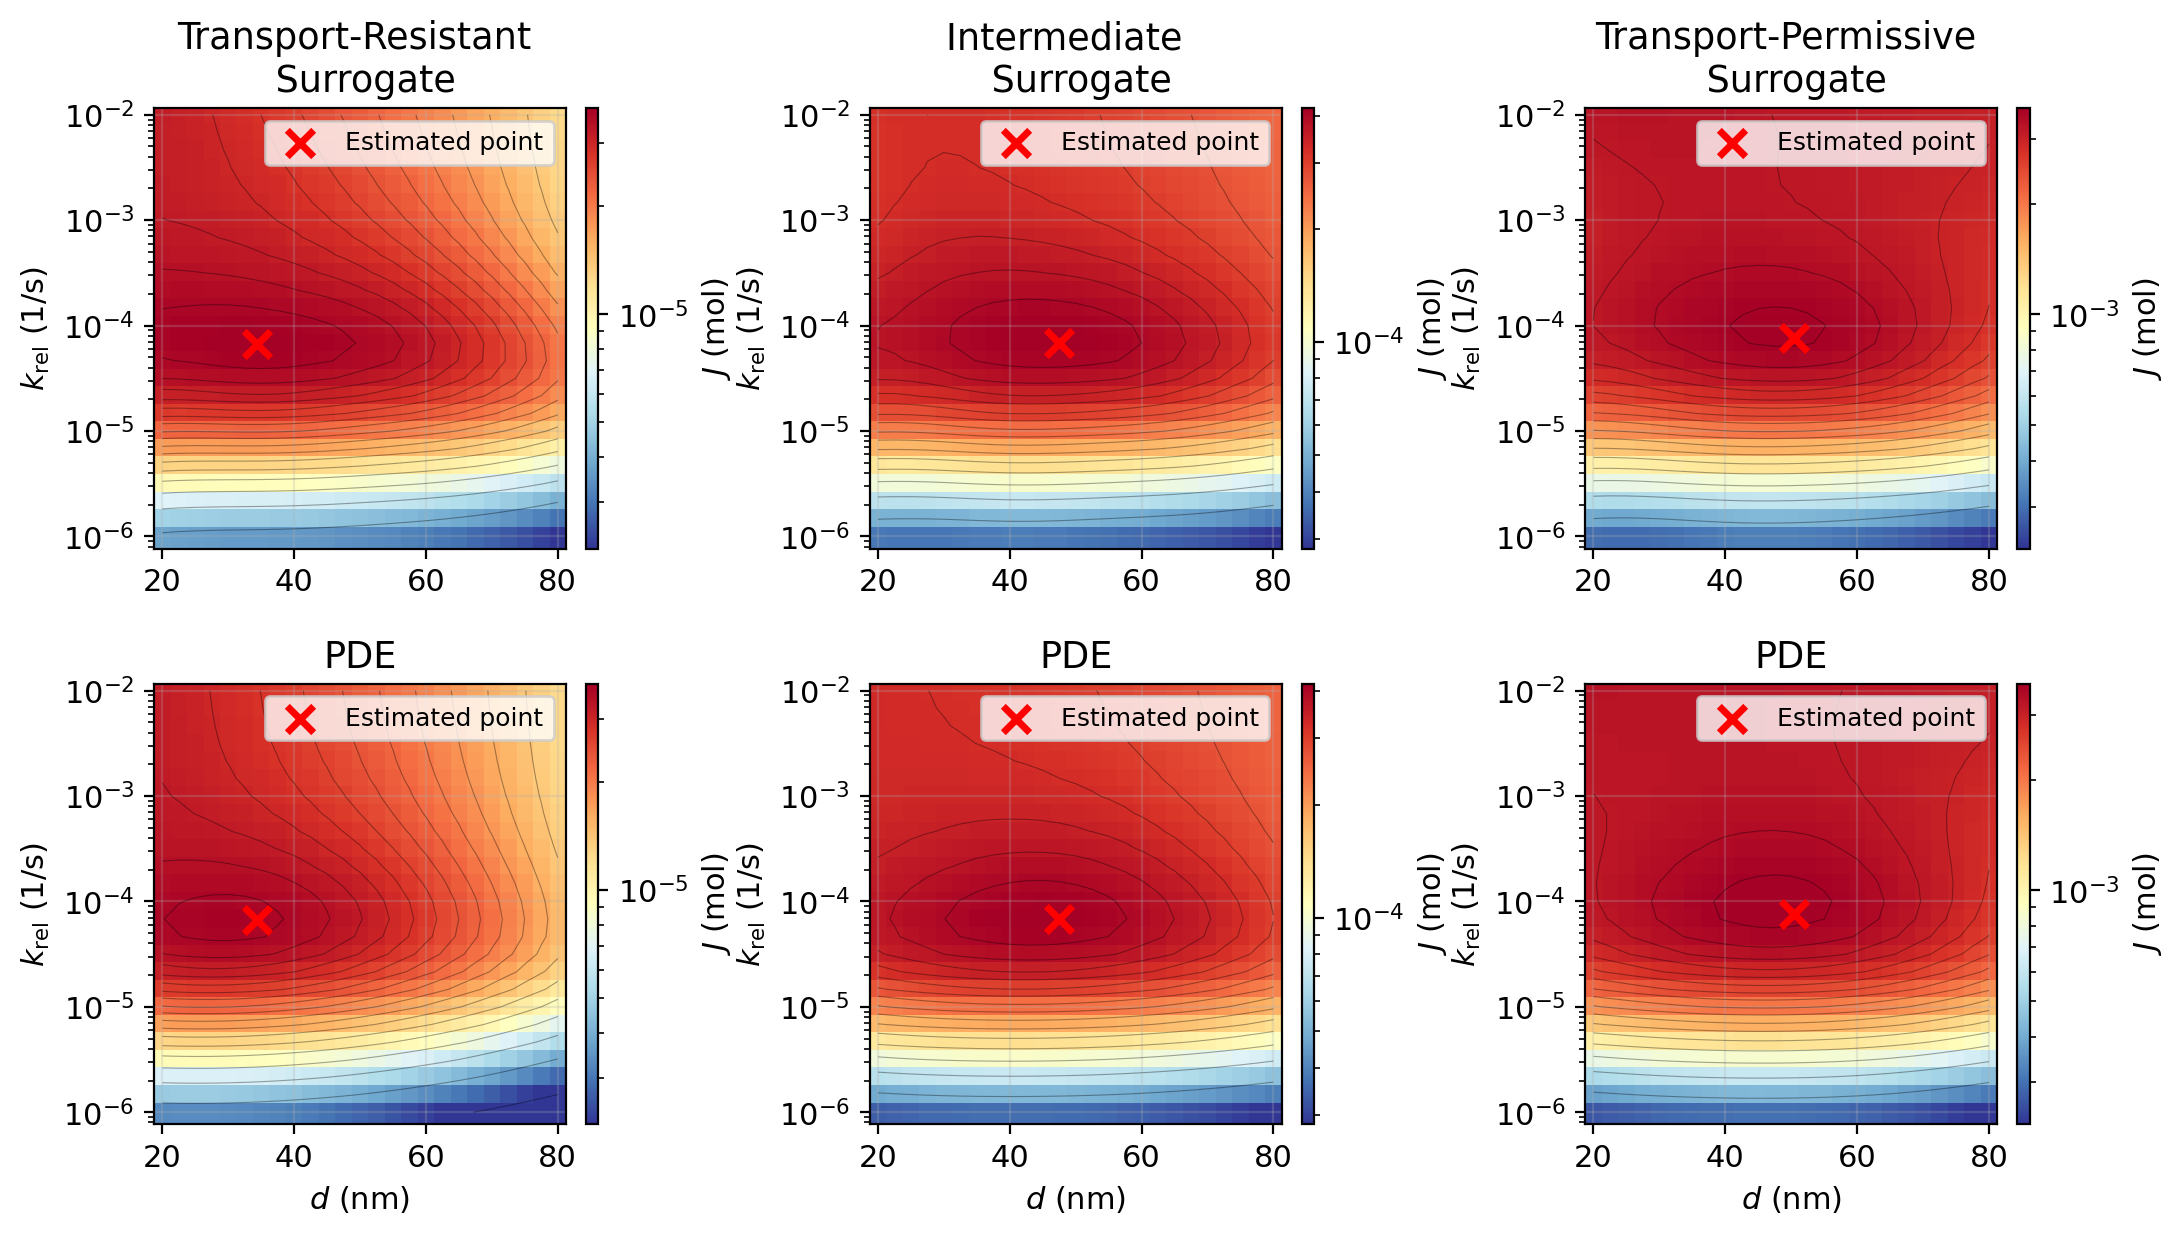

In [22]:
# Comparison of Surrogate and PDE Landscapes for different ECM conditions

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

panel1 = 615
panel2 = 616
panel3 = 617

for i, panel in enumerate([panel1, panel2, panel3]):
    plot_surrogate_landscape_grid(
        [L_surr_list[panel]],
        [L_pde_list[panel]],
        d_vals,
        k_rel_vals,
        [res_list[panel]],
        fig = fig, 
        axes = ax[:,i]
    )
    ax[1, i].set_title("PDE")

ax[0, 0].set_title(f"Transport-Resistant \n Surrogate")
ax[0, 1].set_title(f"Intermediate  \n Surrogate")
ax[0, 2].set_title(f"Transport-Permissive \n Surrogate")

fig._suptitle.remove()

fig.tight_layout()

fig.subplots_adjust(left=0.15, top=0.95)
for i in range(2):
    for j in range(3):
        im = ax[i, j].collections[0]
        cbar = im.colorbar
        cbar.set_label(r"$J$ (mol)")

plt.show()


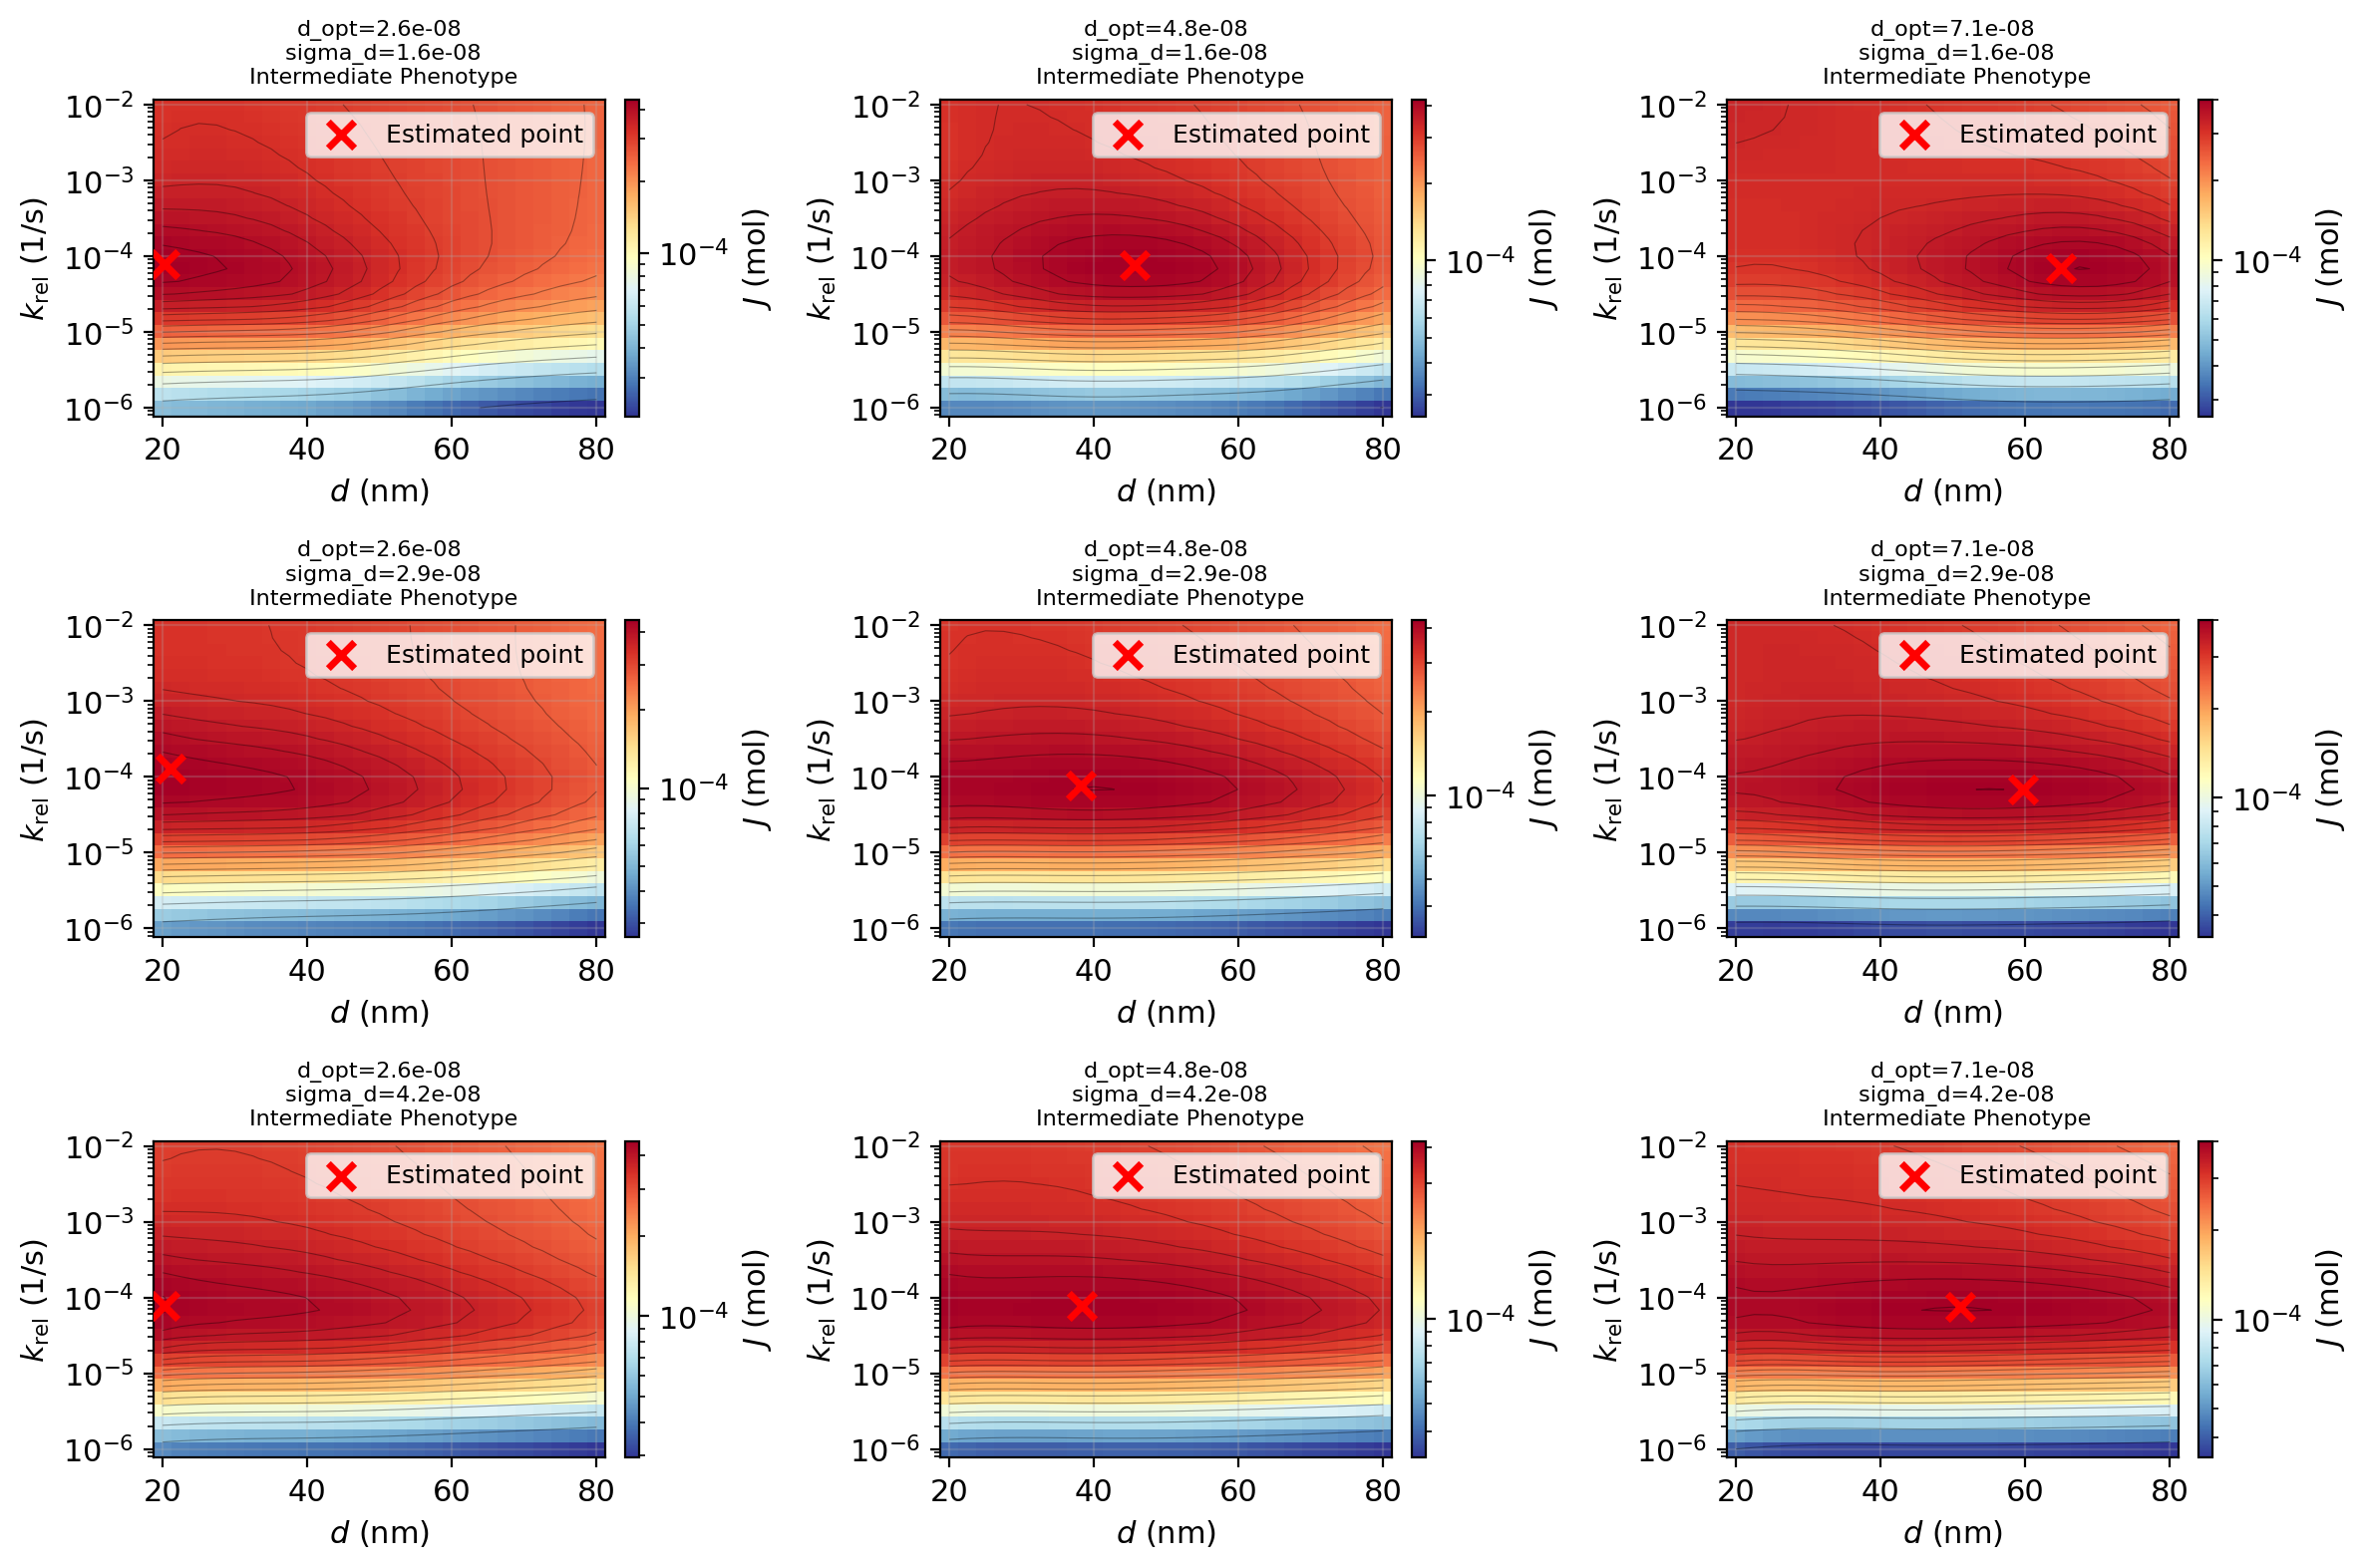

In [23]:
# Comparison of Surrogate Landscapes for different ECM and uptake conditions

panel1 = 130
panel2 = 550
panel3 = 970
panel4 = 148
panel5 = 568
panel6 = 988
panel7 = 166
panel8 = 586
panel9 = 1006

fig, ax = plt.subplots(3, 3, figsize= (12, 8))
for i, panel in enumerate([panel1, panel2, panel3, panel4, panel5, panel6, panel7, panel8, panel9]):
    plot_just_surrogate(
        [L_surr_list[panel]],
        d_vals,
        k_rel_vals,
        [res_list[panel]],
        fig = fig, 
        axes = np.array([ax[i//3, i%3]])
    )
    ax[i//3, i%3].set_title(labels[panel], fontsize= 8)

fig._suptitle.remove()



for i in range(3):
    for j in range(3):
        im = ax[i, j].collections[0]
        cbar = im.colorbar
        cbar.set_label(r"$J$ (mol)")
plt.tight_layout()
plt.show()

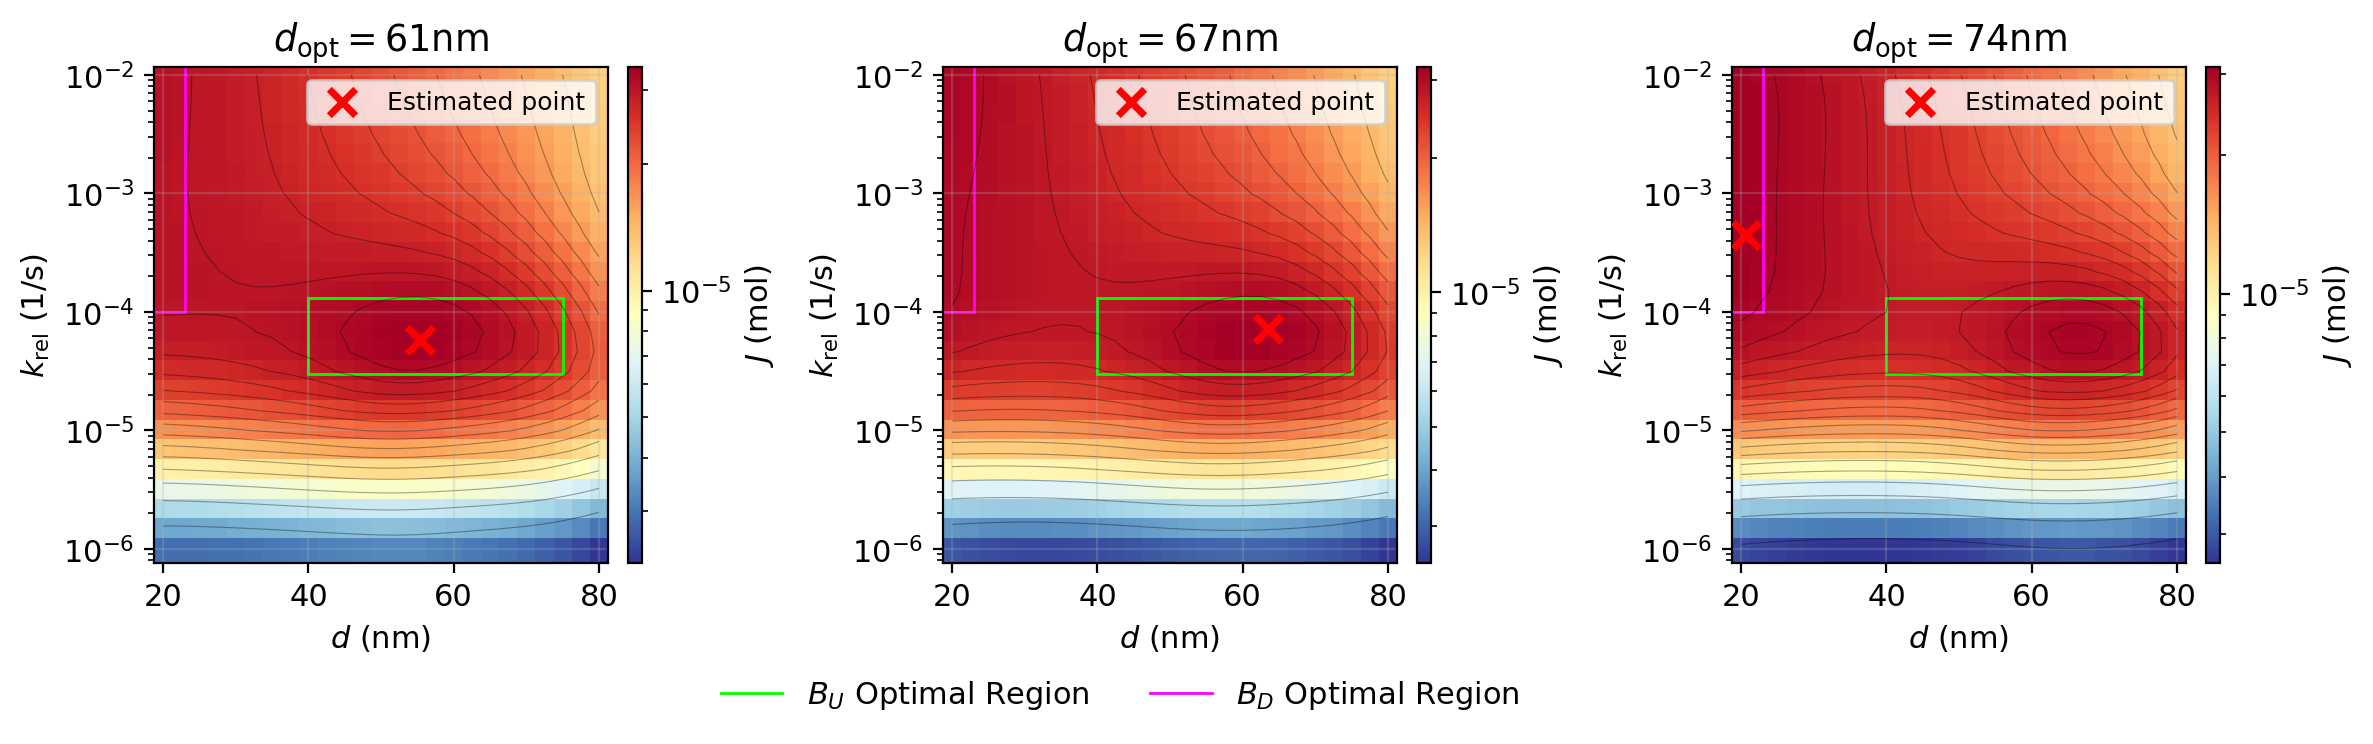

In [92]:
# Highlighting the effect of the transition region of diverging nanoparticle design

panel1 = 786
panel2 = 906
panel3 = 1026


fig, ax = plt.subplots(1, 3, figsize= (12, 3.5))
for i, panel in enumerate([panel1, panel2, panel3]):
    plot_just_surrogate(
        [L_surr_list[panel]],
        d_vals,
        k_rel_vals,
        [res_list[panel]],
        fig = fig, 
        axes = np.array([ax[i]])
    )

ax[0].set_title(r"$d_{\mathrm{opt}} = 61$nm")
ax[1].set_title(r"$d_{\mathrm{opt}} = 67$nm")
ax[2].set_title(r"$d_{\mathrm{opt}} = 74$nm")

B_D_rect0 = patches.Rectangle((18, 1e-4), 5, 1.5e-2 - 1e-4, linewidth=1, edgecolor='magenta', facecolor="none")
ax[0].add_patch(B_D_rect0)
B_D_rect1 = patches.Rectangle((18, 1e-4), 5, 1.5e-2 - 1e-4, linewidth=1, edgecolor='magenta', facecolor="none")
ax[1].add_patch(B_D_rect1)
B_D_rect2 = patches.Rectangle((18, 1e-4), 5, 1.5e-2 - 1e-4, linewidth=1, edgecolor='magenta', facecolor="none")
ax[2].add_patch(B_D_rect2)

B_U_rect0 = patches.Rectangle((40, 3e-5), 35, 1e-4, linewidth=1, edgecolor='lime', facecolor="none")
ax[0].add_patch(B_U_rect0)
B_U_rect1 = patches.Rectangle((40, 3e-5), 35, 1e-4, linewidth=1, edgecolor='lime', facecolor="none")
ax[1].add_patch(B_U_rect1)
B_U_rect2 = patches.Rectangle((40, 3e-5), 35, 1e-4, linewidth=1, edgecolor='lime', facecolor="none")
ax[2].add_patch(B_U_rect2)



fig._suptitle.remove()
legend_handles = [
    Line2D([0], [0], color="lime", linewidth=1, label=r"$B_U$ Optimal Region"),
    Line2D([0], [0], color="magenta", linewidth=1, label=r"$B_D$ Optimal Region")
]
fig.legend(handles=legend_handles, ncol=2, frameon=False, bbox_to_anchor=(0.65, 0.05))




for j in range(3):
    im = ax[j].collections[0]
    cbar = im.colorbar
    cbar.set_label(r"$J$ (mol)")
plt.tight_layout()
plt.show()

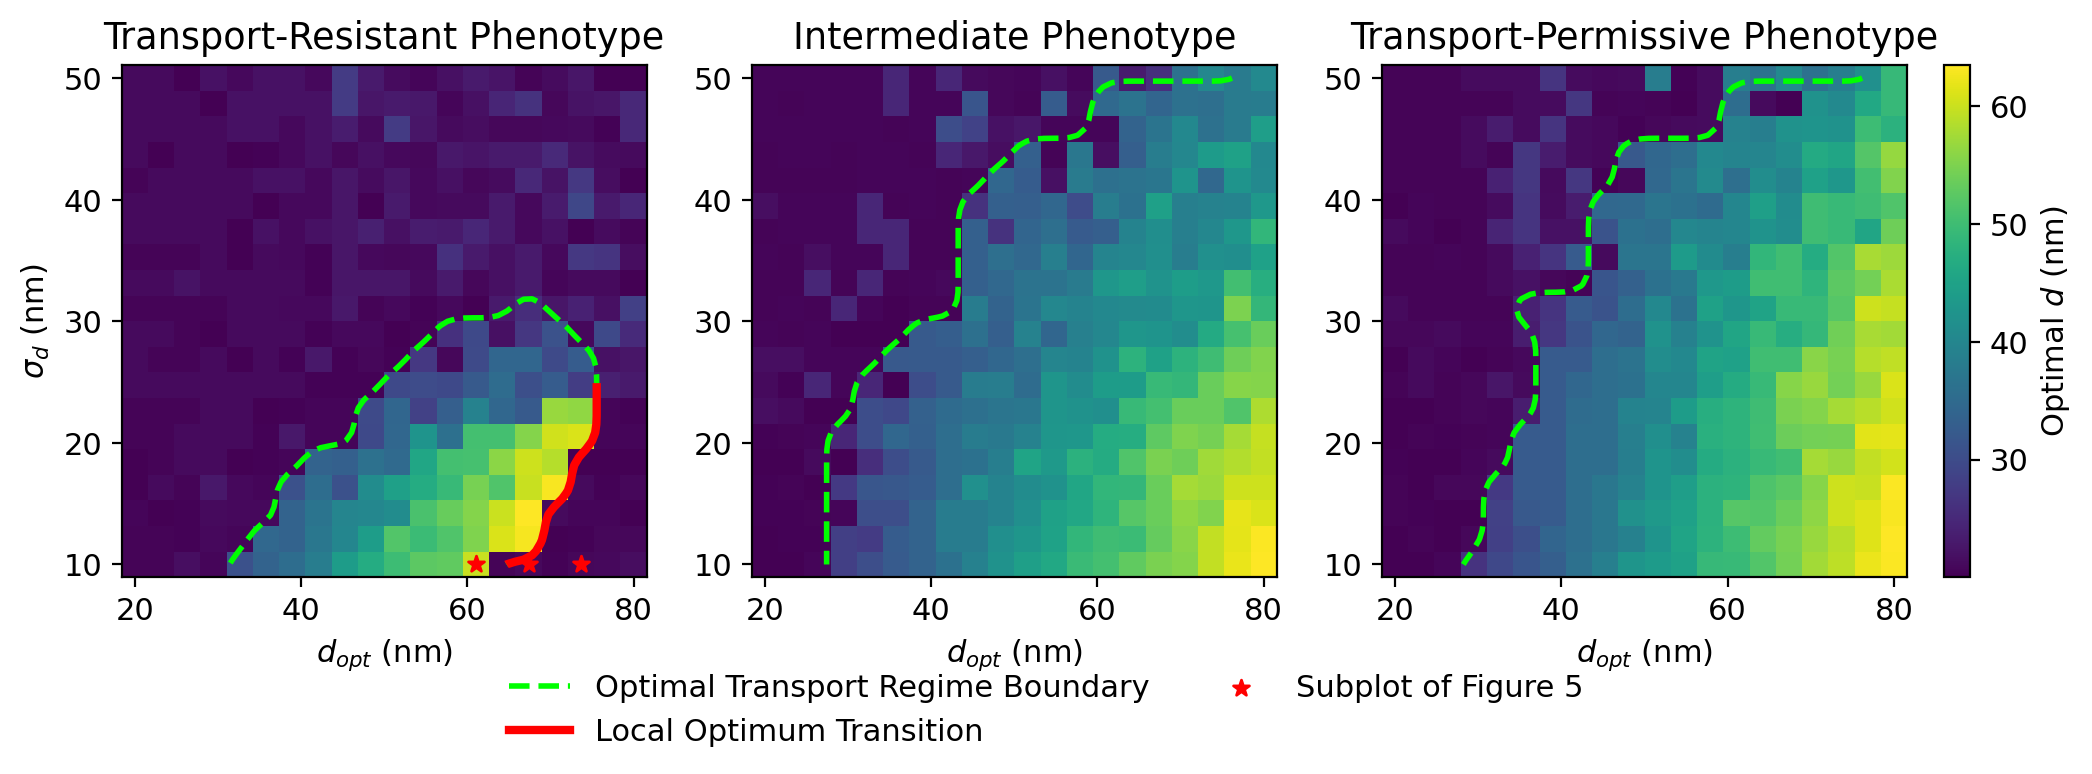

In [7]:
dense_image = []
medium_image = []
loose_image = []
for i in range(20):
    dense_image.append(d_res_list[3*i::60])
    medium_image.append(d_res_list[3*i +1::60])
    loose_image.append(d_res_list[3*i +2::60])

dense_image = np.array(dense_image)
medium_image = np.array(medium_image)
loose_image = np.array(loose_image)

boundary_level = 25
dense_mask = dense_image > boundary_level
medium_mask = medium_image > boundary_level
loose_mask = loose_image > boundary_level



def clean_mask(mask, min_size=10):
    labeled, n = label(mask)

    if n == 0:
        return np.zeros_like(mask, dtype=bool)

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0

    largest = np.argmax(sizes)
    cleaned = labeled == largest

    cleaned = binary_closing(cleaned, structure=np.ones((3, 3)))

    return cleaned

dense_mask_clean = clean_mask(dense_mask, min_size=10)
dense_mask_clean[0,:] += dense_mask[0,:]
dense_mask_clean_zoomed = zoom(dense_mask_clean.astype(float), 3, prefilter=False)


medium_mask_clean = clean_mask(medium_mask, min_size=10)
medium_mask_clean[:,-1] += medium_mask[:,-1]
medium_mask_clean[0,:] += medium_mask[0,:]
medium_mask_clean_zoomed = zoom(medium_mask_clean.astype(float), 3, prefilter=False)


loose_mask_clean = clean_mask(loose_mask, min_size=10)
loose_mask_clean[:,-1] += loose_mask[:,-1]
loose_mask_clean[0,:] += loose_mask[0,:]
loose_mask_clean_zoomed = zoom(loose_mask_clean.astype(float), 3, prefilter= False)



sigma_d_vals_nm = sigma_d_vals * 1e9
d_opt_vals_nm = d_opt_vals * 1e9

sigma_d_vals_nm_zoomed = zoom(sigma_d_vals_nm, 3)
d_opt_vals_nm_zoomed = zoom(d_opt_vals_nm, 3)



X, Y = np.meshgrid(d_opt_vals_nm_zoomed, sigma_d_vals_nm_zoomed)

special_region = (X > 58) & (Y < 25)

dense_special = np.where(
    special_region,
    dense_mask_clean_zoomed,
    np.nan
)

fig, ax = plt.subplots(1, 3, figsize= (12, 4))


im0 = ax[0].pcolormesh(d_opt_vals_nm, sigma_d_vals_nm, dense_image, cmap="viridis")
ax[0].contour( d_opt_vals_nm_zoomed, sigma_d_vals_nm_zoomed, dense_mask_clean_zoomed.astype(float), levels=[0.4], colors="lime", linewidths=2, linestyles="--")
ax[0].contour( d_opt_vals_nm_zoomed, sigma_d_vals_nm_zoomed, dense_special.astype(float), levels=[0.4], colors="red", linewidths=3)
im1 = ax[1].pcolormesh(d_opt_vals_nm, sigma_d_vals_nm, medium_image, cmap="viridis")
ax[1].contour( d_opt_vals_nm_zoomed, sigma_d_vals_nm_zoomed, medium_mask_clean_zoomed.astype(float), levels=[0.4], colors="lime", linewidths=2, linestyles="--")
im2 = ax[2].pcolormesh(d_opt_vals_nm, sigma_d_vals_nm, loose_image, cmap="viridis")
ax[2].contour( d_opt_vals_nm_zoomed, sigma_d_vals_nm_zoomed, loose_mask_clean_zoomed.astype(float), levels=[0.4], colors="lime", linewidths=2, linestyles="--")
ax[0].set_title("Transport-Resistant Phenotype")
ax[1].set_title("Intermediate Phenotype")
ax[2].set_title("Transport-Permissive Phenotype")
ax[0].set_ylabel(r"$\sigma_d$ (nm)")
for i in range(3):
    ax[i].set_xlabel(r"$d_{opt}$ (nm)")
legend_handles = [
    Line2D([0], [0], color="lime", linewidth=2, linestyle="--", label="Optimal Transport Regime Boundary"),
    Line2D([0], [0], color="red", linewidth=3, linestyle="-", label="Local Optimum Transition")
]
legend_handles.append(ax[0].scatter(d_opt_vals_nm[13], sigma_d_vals_nm[0], marker = "*", color = "red", label="Subplot of Figure 5"))
ax[0].scatter(d_opt_vals_nm[15], sigma_d_vals_nm[0], marker = "*", color = "red")
ax[0].scatter(d_opt_vals_nm[17], sigma_d_vals_nm[0], marker = "*", color = "red")
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False)
fig.subplots_adjust(bottom=0.24)
norm = colors.Normalize(vmin=min(d_res_list), vmax=max(d_res_list))
cbar = fig.colorbar(im0, ax=ax.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.02, norm=norm)
cbar.set_label("Optimal $d$ (nm)")




In [59]:
compromise_mask_medium_loose = medium_mask_clean * loose_mask_clean

d_comp_medium = np.where(compromise_mask_medium_loose, medium_image, np.nan).flatten()
d_comp_loose = np.where(compromise_mask_medium_loose, loose_image, np.nan).flatten()

d_comp_medium = d_comp_medium[~np.isnan(d_comp_medium)]
d_comp_loose = d_comp_loose[~np.isnan(d_comp_loose)]


stat, p = wilcoxon(
    d_comp_loose,
    d_comp_medium,
    alternative="greater"
)

print(f"W = {stat:.3f}")
print(f"p = {p:.3e}")


W = 25536.000
p = 4.764e-20


In [27]:
diff = (medium_mask_clean | loose_mask_clean) & ~loose_mask_clean
print(diff.astype(int).sum() / loose_mask_clean.sum())

0.0625


In [28]:
k_dense_image = []
k_medium_image = []
k_loose_image = []
for i in range(20):
    k_dense_image.append(k_rel_res_list[3*i::60])
    k_medium_image.append(k_rel_res_list[3*i +1::60])
    k_loose_image.append(k_rel_res_list[3*i +2::60])

k_dense_image = np.array(k_dense_image)
k_medium_image = np.array(k_medium_image)
k_loose_image = np.array(k_loose_image)

In [29]:
k_comp_dense = np.where(dense_mask_clean, k_dense_image, np.nan).flatten()
k_comp_dense = k_comp_dense[~np.isnan(k_comp_dense)]

k_edge_dense = np.where(~dense_mask_clean, k_dense_image, np.nan).flatten()
k_edge_dense = k_edge_dense[~np.isnan(k_edge_dense)]

k_comp_medium = np.where(medium_mask_clean, k_medium_image, np.nan).flatten()
k_comp_medium = k_comp_medium[~np.isnan(k_comp_medium)]

k_edge_medium = np.where(~medium_mask_clean, k_medium_image, np.nan).flatten()
k_edge_medium = k_edge_medium[~np.isnan(k_edge_medium)]

k_comp_loose = np.where(loose_mask_clean, k_loose_image, np.nan).flatten()
k_comp_loose = k_comp_loose[~np.isnan(k_comp_loose)]

k_edge_loose = np.where(~loose_mask_clean, k_loose_image, np.nan).flatten()
k_edge_loose = k_edge_loose[~np.isnan(k_edge_loose)]


def remove_outliers_iqr(x, multiplier=1.5):
    """Remove values outside [Q1 - multiplier*IQR, Q3 + multiplier*IQR]."""
    x = np.asarray(x)

    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    return x[(x >= lower) & (x <= upper)]

k_comp_dense_clean = remove_outliers_iqr(k_comp_dense)
k_edge_dense_clean = remove_outliers_iqr(k_edge_dense)

k_comp_medium_clean = remove_outliers_iqr(k_comp_medium)
k_edge_medium_clean = remove_outliers_iqr(k_edge_medium)

k_comp_loose_clean = remove_outliers_iqr(k_comp_loose)
k_edge_loose_clean = remove_outliers_iqr(k_edge_loose)

score_dense, p_dense = mannwhitneyu(
    k_comp_dense_clean,
    k_edge_dense_clean,
    alternative="two-sided"
)

score_medium, p_medium = mannwhitneyu(
    k_comp_medium_clean,
    k_edge_medium_clean,
    alternative="two-sided"
)

score_loose, p_loose = mannwhitneyu(
    k_comp_loose_clean,
    k_edge_loose_clean,
    alternative="two-sided"
)

print(
    f"Dense ECM Compromise NP mean k_rel: "
    f"{k_comp_dense_clean.mean():.4g}, "
    f"sd {k_comp_dense_clean.std():.4g}, "
    f"n = {len(k_comp_dense_clean)}"
)

print(
    f"Dense ECM Edge NP mean k_rel: "
    f"{k_edge_dense_clean.mean():.4g}, "
    f"sd {k_edge_dense_clean.std():.4g}, "
    f"n = {len(k_edge_dense_clean)}"
)

print(
    f"Intermediate ECM Compromise NP mean k_rel: "
    f"{k_comp_medium_clean.mean():.4g}, "
    f"sd {k_comp_medium_clean.std():.4g}, "
    f"n = {len(k_comp_medium_clean)}"
)

print(
    f"Intermediate ECM Edge NP mean k_rel: "
    f"{k_edge_medium_clean.mean():.4g}, "
    f"sd {k_edge_medium_clean.std():.4g}, "
    f"n = {len(k_edge_medium_clean)}"
)

print(
    f"Loose ECM Compromise NP mean k_rel: "
    f"{k_comp_loose_clean.mean():.4g}, "
    f"sd {k_comp_loose_clean.std():.4g}, "
    f"n = {len(k_comp_loose_clean)}"
)

print(
    f"Loose ECM Edge NP mean k_rel: "
    f"{k_edge_loose_clean.mean():.4g}, "
    f"sd {k_edge_loose_clean.std():.4g}, "
    f"n = {len(k_edge_loose_clean)}"
)

print(f"p-value for dense: {p_dense:.2g}")
print(f"p-value for intermediate: {p_medium:.2g}")
print(f"p-value for loose: {p_loose:.2g}")




Dense ECM Compromise NP mean k_rel: 6.757e-05, sd 6.635e-06, n = 86
Dense ECM Edge NP mean k_rel: 7.677e-05, sd 5.286e-06, n = 231
Intermediate ECM Compromise NP mean k_rel: 7.268e-05, sd 6.715e-06, n = 259
Intermediate ECM Edge NP mean k_rel: 7.602e-05, sd 5.297e-06, n = 110
Loose ECM Compromise NP mean k_rel: 9.527e-05, sd 1.048e-05, n = 245
Loose ECM Edge NP mean k_rel: 9.671e-05, sd 2.066e-05, n = 143
p-value for dense: 2.3e-24
p-value for intermediate: 8.5e-07
p-value for loose: 0.69


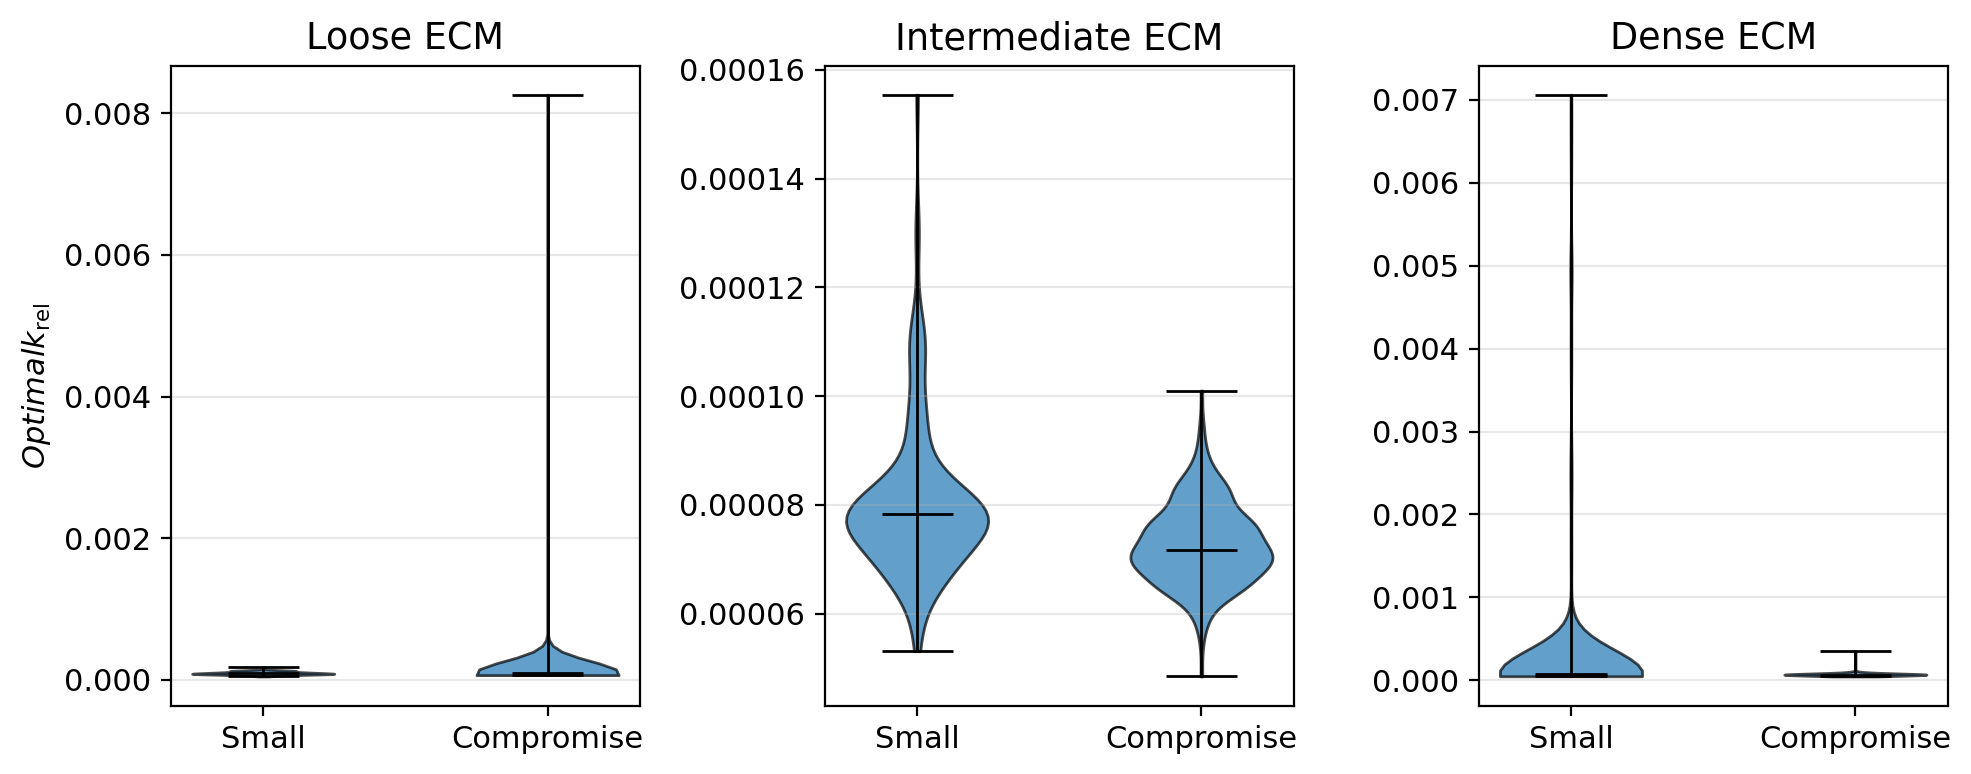

In [30]:
data = {
    "Loose ECM": {
        "Edge": k_edge_loose,
        "Compromise": k_comp_loose,
    },
    "Intermediate ECM": {
        "Edge": k_edge_medium,
        "Compromise": k_comp_medium,
    },
    "Dense ECM": {
        "Edge": k_edge_dense,
        "Compromise": k_comp_dense,
    },
}
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (phenotype, vals) in zip(axes, data.items()):
    parts = ax.violinplot(
        [vals["Edge"], vals["Compromise"]],
        positions=[1, 2],
        showmeans=False,
        showmedians=True,
        showextrema=True,
    )
    for body in parts["bodies"]:
        body.set_alpha(0.7)
        body.set_edgecolor("black")
    for key in ["cmedians", "cmins", "cmaxes", "cbars"]:
        if key in parts:
            parts[key].set_color("black")
            parts[key].set_linewidth(1)

    ax.set_title(phenotype)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Small", "Compromise"])

    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel(r"$Optimal k_\mathrm{rel}$")

fig.tight_layout()
plt.show()

In [31]:
X, Y = np.meshgrid(d_opt_vals_nm, sigma_d_vals_nm)

special_region = (X > 58) & (Y < 25)

dense_special = ~np.where(special_region, dense_mask_clean, 1).astype(bool)

In [32]:
k_nonspecial_dense = np.where(~dense_special, k_dense_image, np.nan).flatten()
k_nonspecial_dense = k_nonspecial_dense[~np.isnan(k_nonspecial_dense)]

k_special_dense = np.where(dense_special, k_dense_image, np.nan).flatten()
k_special_dense = k_special_dense[~np.isnan(k_special_dense)]

score_special, p_special = mannwhitneyu(
    k_special_dense,
    k_nonspecial_dense,
    alternative="two-sided"
)

print(
    f"Dense ECM breakdown region k_rel: "
    f"{k_special_dense.mean():.4g}, "
    f"sd {k_special_dense.std():.4g}, "
    f"n = {len(k_special_dense)}"
)

print(
    f"Dense ECM rest mean k_rel: "
    f"{k_nonspecial_dense.mean():.4g}, "
    f"sd {k_nonspecial_dense.std():.4g}, "
    f"n = {len(k_nonspecial_dense)}"
)

print(f"p-value for difference: {p_special:.2g}")


Dense ECM breakdown region k_rel: 0.002268, sd 0.00232, n = 25
Dense ECM rest mean k_rel: 7.587e-05, sd 1.815e-05, n = 375
p-value for difference: 2.4e-17


In [33]:
data_params_list = []
for p in phys_list:
    data_params = DatasetParameters(save=False, d_val_m=np.array([p.d_val_m]), k_rel= np.array([p.k_rel]))
    data_params_list.append(data_params)

def make_data_single(p, d):
    dataset = make_dataset(p, SimulationParameters(), d)
    dataset["CI"] = dataset["CI"][0,0]
    return dataset

In [34]:
time_inv_surr_maker = lambda i, d : i.invert(make_data_single(i.phys, d), "mse", timing= True)
time_inv_pde_maker = lambda i, d : i.invert(make_data_single(i.phys, d), "mse_sim", timing= True)


time_opt_surr_maker = lambda i : i.invert(data_const, "CI", timing= True)
time_opt_pde_maker = lambda i : i.invert(data_const, "CI_sim", timing= True)

num_cpus = 200
surr_inv_time_list = p_map(time_inv_surr_maker, inv_list, data_params_list, num_cpus= num_cpus)
pde_inv_time_list = p_map(time_inv_pde_maker, inv_list, data_params_list, num_cpus= num_cpus)
surr_opt_time_list = p_map(time_opt_surr_maker, inv_list, num_cpus= num_cpus)
pde_opt_time_list  = p_map(time_opt_pde_maker, inv_list, num_cpus= num_cpus)

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  1.86it/s]

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  2.04it/s]

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  1.80it/s]

  0%|          | 0/1200 [00:26<?, ?it/s]Process ForkPoolWorker-3322:
Process ForkPoolWorker-3330:
Process ForkPoolWorker-3348:
Process ForkPoolWorker-3321:
Process ForkPoolWorker-3339:
Process ForkPoolWorker-3338:
Process ForkPoolWorker-3327:
Process ForkPoolWorker-3337:
Process ForkPoolWorker-3311:
Process ForkPoolWorker-3319:
Process ForkPoolWorker-3331:
Process ForkPoolWorker-3316:
Process ForkPoolWorker-3312:
Process ForkPoolWorker-3318:
Process ForkPoolWorker-3309:
Process ForkPoolWorker-3302:
Process ForkPoolWorker-3328:
Process ForkPoolWorker-3334:
Process ForkPoolWorker-3291:
Process ForkPoolWorker-3346:
Process ForkPoolWorker-3333:
Process ForkPoolWorker-3294:
Process ForkPoolWorker-3323:
Process ForkPoolWorker-3345:
Process ForkPoolWorker-3292:
Process For

KeyboardInterrupt: 

Process ForkPoolWorker-3326:
Process ForkPoolWorker-3278:
Process ForkPoolWorker-3288:
Process ForkPoolWorker-3305:
Process ForkPoolWorker-3290:
Process ForkPoolWorker-3295:
Process ForkPoolWorker-3324:
Process ForkPoolWorker-3342:
Process ForkPoolWorker-3301:
Process ForkPoolWorker-3277:
Process ForkPoolWorker-3303:
Process ForkPoolWorker-3332:
Process ForkPoolWorker-3306:
Process ForkPoolWorker-3325:
Process ForkPoolWorker-3335:
Process ForkPoolWorker-3296:


Process ForkPoolWorker-3282:
Process ForkPoolWorker-3280:
Process ForkPoolWorker-3285:
Process ForkPoolWorker-3344:
Process ForkPoolWorker-3299:
Process ForkPoolWorker-3289:
Process ForkPoolWorker-3283:
Process ForkPoolWorker-3279:
Process ForkPoolWorker-3287:
Process ForkPoolWorker-3336:
Process ForkPoolWorker-3286:
Process ForkPoolWorker-3298:
Process ForkPoolWorker-3284:
Process ForkPoolWorker-3297:
Process ForkPoolWorker-3300:
Process ForkPoolWorker-3281:
Process ForkPoolWorker-3341:
Process ForkPoolWorker-3343:
Process ForkPoolWorker-3275:
Process ForkPoolWorker-3349:
Process ForkPoolWorker-3351:
Process ForkPoolWorker-3379:
Process ForkPoolWorker-3276:
Process ForkPoolWorker-3347:
Process ForkPoolWorker-3436:
Process ForkPoolWorker-3352:
Process ForkPoolWorker-3421:
Process ForkPoolWorker-3445:
Process ForkPoolWorker-3373:
Process ForkPoolWorker-3442:
Process ForkPoolWorker-3399:
Process ForkPoolWorker-3358:
Process ForkPoolWorker-3368:
Process ForkPoolWorker-3372:
Process ForkPo

In [ ]:
print(np.mean(surr_opt_time_list))
print(np.std(surr_opt_time_list))
print(np.mean(pde_opt_time_list))
print(np.std(pde_opt_time_list))

11.22108292384306
3.802703287631415
85.47587516459055
41.31402004188958


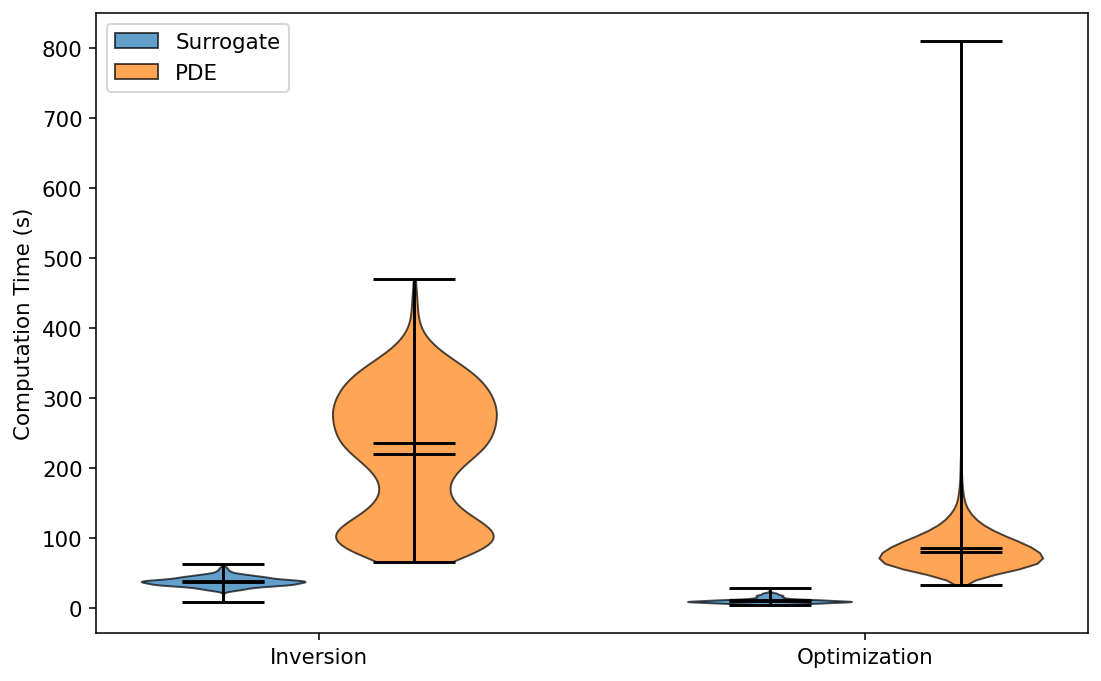

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

positions = [1.0, 1.35, 2.0, 2.35]

parts = ax.violinplot(
    [
        surr_inv_time_list,
        pde_inv_time_list,
        surr_opt_time_list,
        pde_opt_time_list,
    ],
    positions=positions,
    widths=0.3,
    showmeans=True,
    showmedians=True,
)

surrogate_color = "tab:blue"
pde_color = "tab:orange"

colors = [
    surrogate_color,
    pde_color,
    surrogate_color,
    pde_color,
]

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)


for key in ["cmeans", "cmedians", "cmins", "cmaxes", "cbars"]:
    parts[key].set_color("black")

ax.set_xticks([1.175, 2.175])
ax.set_xticklabels(["Inversion", "Optimization"])

ax.set_ylabel("Computation Time (s)")

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(
            facecolor=surrogate_color,
            edgecolor="black",
            alpha=0.7,
            label="Surrogate",
        ),
        Patch(
            facecolor=pde_color,
            edgecolor="black",
            alpha=0.7,
            label="PDE",
        ),
    ]
)

plt.tight_layout()
plt.show()

# Ablation Study

In [8]:
ablate_loading_model = t.load(f"{ROOT}/data/ablate_loading_model.pt", weights_only= False)
ablate_transport_model = t.load(f"{ROOT}/data/ablate_transport_model.pt", weights_only= False)
ablate_uptake_model = t.load(f"/{ROOT}/data/ablate_uptake_model.pt", weights_only= False)

ablate_loading_inv = SurrogateInversion(ablate_loading_model, InversionParameters(), PhysicsConstants(), SimulationParameters())
ablate_transport_inv = SurrogateInversion(ablate_transport_model, InversionParameters(), PhysicsConstants(), SimulationParameters())
ablate_uptake_inv = SurrogateInversion(ablate_uptake_model, InversionParameters(), PhysicsConstants(), SimulationParameters())

In [9]:
L_surf_maker = lambda i: i.loss_surface(data_const, d_vals, k_rel_vals, "CI")
inv_maker = lambda i: i.invert(data_const, "CI")
inv_list = [ablate_loading_inv, ablate_transport_inv, ablate_uptake_inv]
L_surf_ablation = p_map(L_surf_maker, inv_list)
inv_ablation = p_map(inv_maker, inv_list)


100%|██████████| 3/3 [00:13<00:00,  4.61s/it]


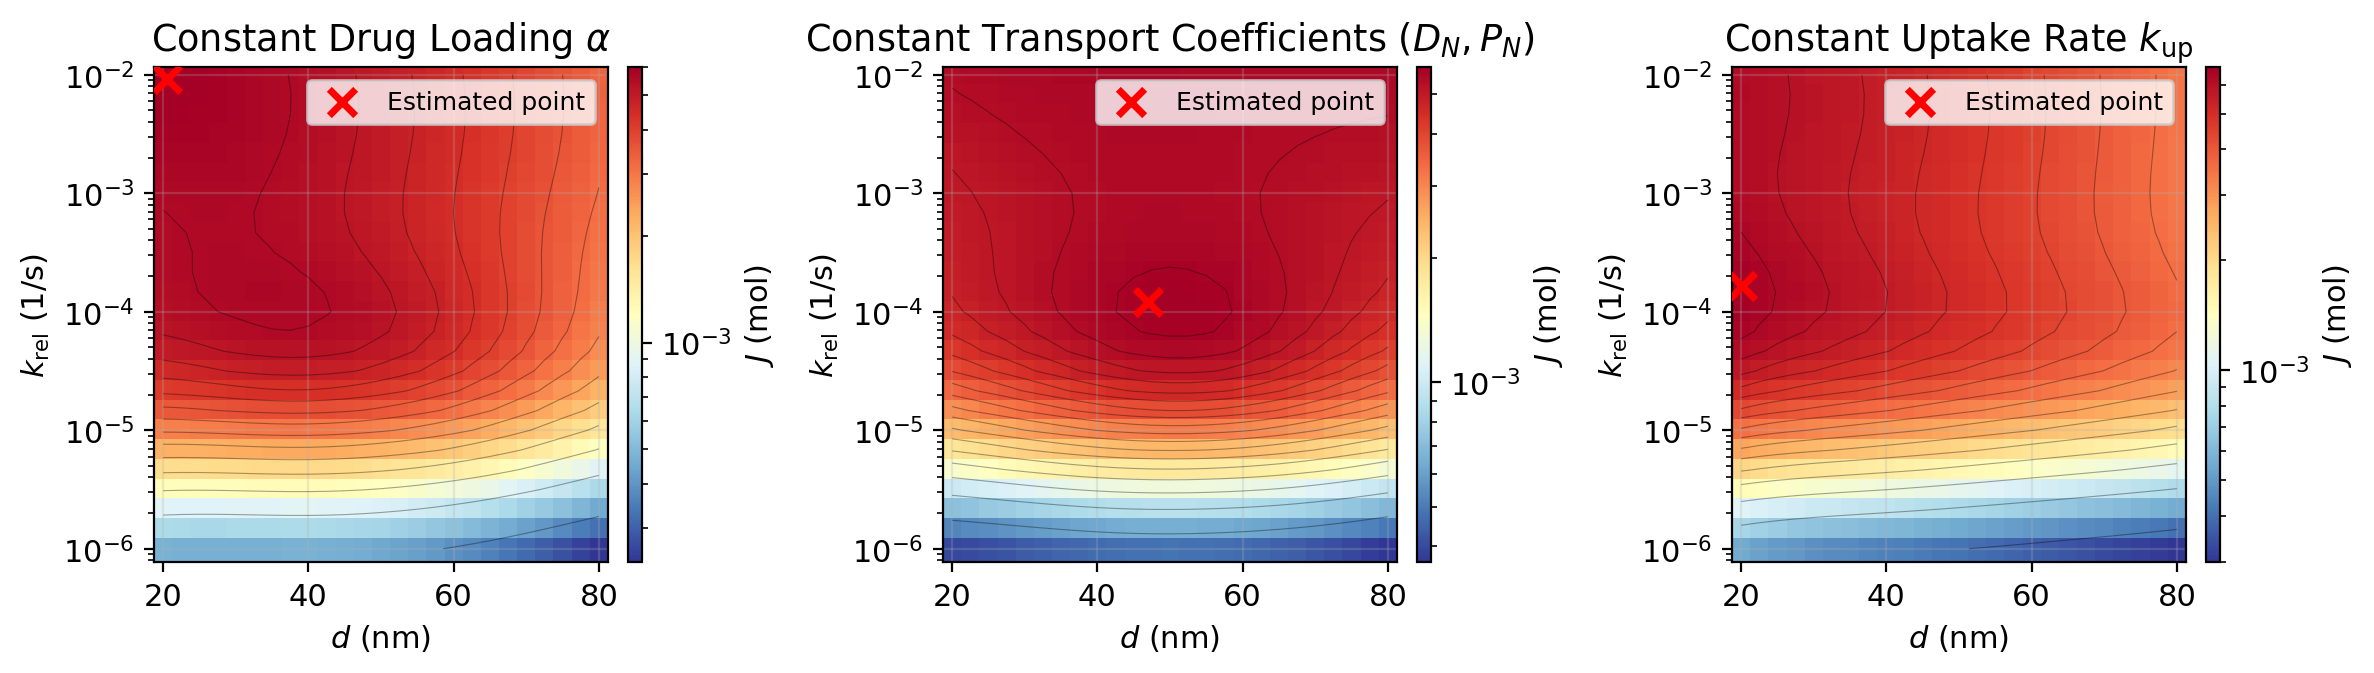

In [10]:
fig, ax = plt.subplots(1, 3, figsize= (12, 3.5))
for i in range(3):
    plot_just_surrogate(
        [L_surf_ablation[i]],
        d_vals,
        k_rel_vals,
        [inv_ablation[i]],
        fig = fig, 
        axes = np.array([ax[i]])
    )
for a in ax:
    im = a.collections[0]
    cbar = im.colorbar
    cbar.set_label(r"$J$ (mol)")
ax[0].set_title(r"Constant Drug Loading $\alpha$")
ax[1].set_title(r"Constant Transport Coefficients ($D_N, P_N$)")
ax[2].set_title(r"Constant Uptake Rate $k_\mathrm{up}$")
fig._suptitle.remove()
fig.tight_layout()


# Transition Region Investigation

In [8]:
P0_vals = [1e-10, 1e-9, 1e-8]
d_pore_vals = [80e-9, 150e-9, 300e-9]
xi_ECM_vals = [25e-9, 60e-9, 120e-9]
ECM_options = ["Transport-Resistant", "Intermediate", "Transport-Permissive"]


In [9]:
trans_model_list = []
trans_inv_list = []
trans_phys_list = []
trans_labels = []

# Dense ECM normal transfer region
d_opt_vals = np.linspace(30e-9, 50e-9, 100)
sigma_d_vals = np.linspace(15e-9, 30e-9, 100)[::-1]
for d_opt, sigma_d in zip(d_opt_vals, sigma_d_vals):
    d_pore = d_pore_vals[0]
    xi_ECM = xi_ECM_vals[0]
    P0 = P0_vals[0]
    trans_labels.append(f"d_opt={d_opt:.4g}\n sigma_d={sigma_d:.4g}\n {ECM_options[0]} Phenotype")
    trans_phys_list.append(PhysicsConstants(P0= P0, d_pore=d_pore, xi_ECM=xi_ECM, d_opt=d_opt, sigma_d=sigma_d))
    trans_model_list.append(t.load(f"{ROOT}/data/d_opt={d_opt:.4g}_sigma_d={sigma_d:.4g}_d_pore={d_pore:.4g}_model.pt", weights_only= False))
    trans_inv_list.append(SurrogateInversion(trans_model_list[-1], InversionParameters(), trans_phys_list[-1], params))


# Intermediate ECM normal transfer region
d_opt_vals = np.linspace(35-9, 55e-9, 100)
sigma_d_vals = np.linspace(30e-9, 45-9, 100)[::-1]
for d_opt, sigma_d in zip(d_opt_vals, sigma_d_vals):
    d_pore = d_pore_vals[1]
    xi_ECM = xi_ECM_vals[1]
    P0 = P0_vals[1]
    trans_labels.append(f"d_opt={d_opt:.4g}\n sigma_d={sigma_d:.4g}\n {ECM_options[1]} ECM")
    trans_phys_list.append(PhysicsConstants(P0= P0, d_pore=d_pore, xi_ECM=xi_ECM, d_opt=d_opt, sigma_d=sigma_d))
    trans_model_list.append(t.load(f"{ROOT}/data/d_opt={d_opt:.4g}_sigma_d={sigma_d:.4g}_d_pore={d_pore:.4g}_model.pt", weights_only= False))
    trans_inv_list.append(SurrogateInversion(trans_model_list[-1], InversionParameters(), trans_phys_list[-1], params))

# Loose ECM normal transfer region
d_opt_vals = np.linspace(35-9, 55e-9, 100)
sigma_d_vals = np.linspace(30e-9, 45-9, 100)[::-1]
for d_opt, sigma_d in zip(d_opt_vals, sigma_d_vals):
    d_pore = d_pore_vals[2]
    xi_ECM = xi_ECM_vals[2]
    P0 = P0_vals[2]
    trans_labels.append(f"d_opt={d_opt:.4g}\n sigma_d={sigma_d:.4g}\n {ECM_options[2]} ECM")
    trans_phys_list.append(PhysicsConstants(P0= P0, d_pore=d_pore, xi_ECM=xi_ECM, d_opt=d_opt, sigma_d=sigma_d))
    trans_model_list.append(t.load(f"{ROOT}/data/d_opt={d_opt:.4g}_sigma_d={sigma_d:.4g}_d_pore={d_pore:.4g}_model.pt", weights_only= False))
    trans_inv_list.append(SurrogateInversion(trans_model_list[-1], InversionParameters(), trans_phys_list[-1], params))

# Special dense region
d_opt_vals = np.linspace(60e-9, 80e-9, 100)
sigma_d_vals = np.ones(100) * 15e-9
for d_opt, sigma_d in zip(d_opt_vals, sigma_d_vals):
    d_pore = d_pore_vals[0]
    xi_ECM = xi_ECM_vals[0]
    P0 = P0_vals[0]
    trans_labels.append(f"d_opt={d_opt:.4g}\n sigma_d={sigma_d:.4g}\n {ECM_options[0]} ECM")
    trans_phys_list.append(PhysicsConstants(P0= P0, d_pore=d_pore, xi_ECM=xi_ECM, d_opt=d_opt, sigma_d=sigma_d))
    trans_model_list.append(t.load(f"{ROOT}/data/d_opt={d_opt:.4g}_sigma_d={sigma_d:.4g}_d_pore={d_pore:.4g}_model.pt", weights_only= False))
    trans_inv_list.append(SurrogateInversion(trans_model_list[-1], InversionParameters(), trans_phys_list[-1], params))

In [10]:
surr_maker = lambda i: i.loss_surface(data_const, d_vals, k_rel_vals, "CI")
res_maker = lambda i : i.invert(data_const, "CI")

trans_L_surf_list = p_map(surr_maker, trans_inv_list)
trans_inv_res_list = p_map(res_maker, trans_inv_list)

100%|██████████| 400/400 [02:33<00:00,  2.61it/s]


In [11]:
from scipy.ndimage import maximum_filter
from scipy.optimize import minimize


def find_local_minima(
    loss_func,
    loss_grid,
    x_vals,
    y_vals,
    x_bounds,
    y_bounds,
    neighborhood_size=3,
    uniqueness_tol=1e-6,
):
    loss_grid = np.asarray(loss_grid).T

    

    if loss_grid.shape != (len(y_vals), len(x_vals)):
        raise ValueError(
            f"loss_grid has shape {loss_grid.shape}, but expected "
            f"({len(y_vals)}, {len(x_vals)})"
        )

    filtered = maximum_filter(
        loss_grid,
        size=neighborhood_size,
        mode="nearest",
    )

    candidate_mask = loss_grid == filtered

    candidate_indices = np.argwhere(candidate_mask)

    minima = []

    for iy, ix in candidate_indices:

        initial_guess = np.array([
            x_vals[ix],
            y_vals[iy],
        ])

        #print(initial_guess)

        result = minimize(
            loss_func,
            initial_guess,
            method="Nelder-Mead",
            bounds=[
                x_bounds,
                y_bounds,
            ],
        )

        if not result.success:
            continue

        minima.append((
            result.x[0],
            result.x[1],
            result.fun,
        ))


    unique_minima = []

    minima.sort(key=lambda m: m[2])

    for minimum in minima:

        x_min, y_min, loss_min = minimum

        is_duplicate = any(
            np.linalg.norm(
                np.array([x_min, y_min])
                - np.array([x_prev, y_prev])
            ) < uniqueness_tol
            for x_prev, y_prev, _ in unique_minima
        )

        if not is_duplicate:
            unique_minima.append(minimum)

    return unique_minima

In [12]:
def mins_single_idx(i):
    trans_inv_list[i]._load_data(data_const)
    mins = find_local_minima(
        trans_inv_list[i]._CI,
        trans_L_surf_list[i],
        d_vals,
        np.log(k_rel_vals),
        (20e-9, 80e-9),
        (np.log(1e-6), np.log(1e-2))
        )
    mins_d = [m[0] * 1e9 for m in mins]
    mins_k = [np.exp(m[1]) for m in mins]
    mins_loss = [np.exp(-m[2]) for m in mins]
    return (mins_d, mins_k, mins_loss)

trans_res_mins = p_map(mins_single_idx, range(400))

100%|██████████| 400/400 [01:15<00:00,  5.33it/s]


In [13]:
def make_frame(i, fig= None):
    if i // 100 == 0:
        image = dense_image
    elif i // 100 == 1:
        image = medium_image
    elif i // 100 == 2:
        image = loose_image
    else:
        image = dense_image
    if fig is None:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    else:
        fig.clear()
        ax = fig.subplots(1, 2)

    plot_just_surrogate(
            [trans_L_surf_list[i]],
            d_vals,
            k_rel_vals,
            [trans_inv_res_list[i]],
            fig = fig, 
            axes = np.array([ax[0]])
        )
    
    ax[0].scatter(trans_res_mins[i][0], trans_res_mins[i][1])


    im0 = ax[0].collections[0]
    cbar = im0.colorbar
    cbar.set_label(r"$J$ (mol)")
    im1 = ax[1].pcolormesh(d_opt_vals_nm, sigma_d_vals_nm, image, cmap="viridis")
    ax[1].set_ylabel(r"$\sigma_d$ (nm)")
    ax[1].set_xlabel(r"$d_{opt}$ (nm)")
    ax[1].scatter(trans_phys_list[i].d_opt * 1e9, trans_phys_list[i].sigma_d * 1e9, c= "magenta", label= "Location in Parameter Space")
    ax[1].legend()
    fig.colorbar(im1, ax=ax[1], orientation='vertical', label=r"Optimal $d$ (nm)")
    fig._suptitle.remove()
    fig.tight_layout()
    return fig, ax




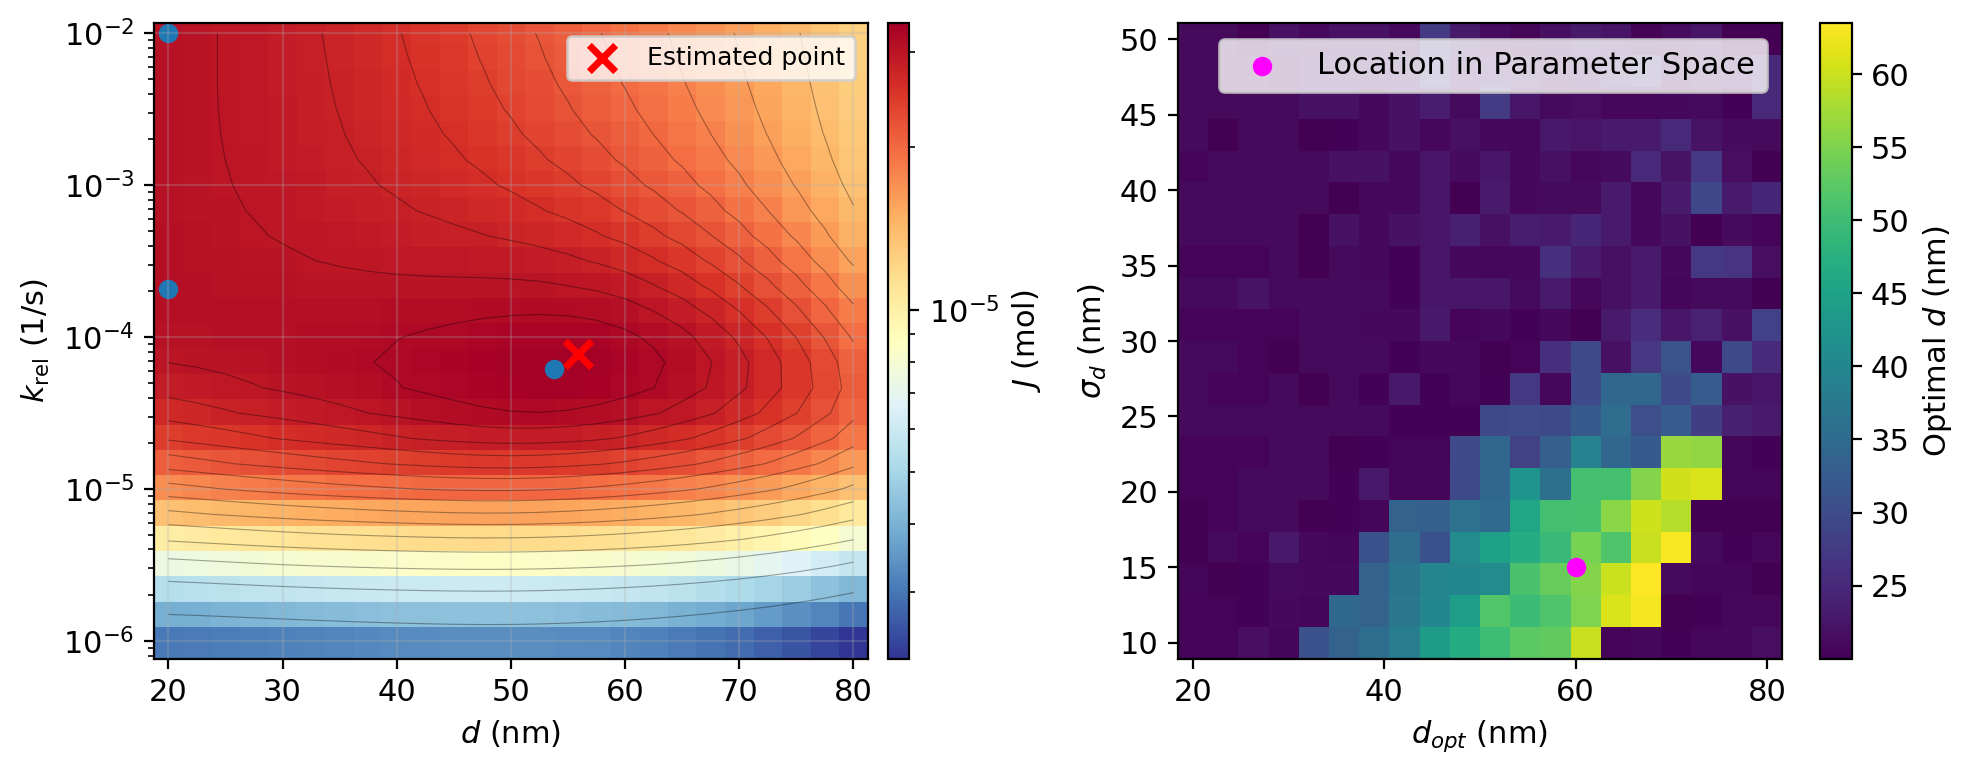

In [14]:
from matplotlib.animation import FuncAnimation
fig, ax = make_frame(300)


def update(i):
    fig.clear()
    make_frame(i, fig=fig)
    return ax,

ani = FuncAnimation(
    fig,
    update,
    frames=range(300, 400),
    interval=100,
    blit=False
)
ani.save(
    "animation.mp4",
    writer="ffmpeg",
    fps=10
)


In [30]:
param_dict_list = []
loss_dict_list = []
for res in trans_res_mins[300:]:
    loss_res_dict = {}
    param_res_dict = {}
    for i in range(len(res[0])):
        if res[0][i] > 25:
            loss_res_dict["B_U"] = res[2][i]
            param_res_dict["B_U"] = (res[0][i], res[1][i])
        elif res[1][i] < 1e-3 :
            loss_res_dict["B_D_low_k_rel"] = res[2][i]
            param_res_dict["B_D_low_k_rel"] = (res[0][i], res[1][i])
        else:
            loss_res_dict["B_D_high_k_rel"] = res[2][i]
            param_res_dict["B_D_high_k_rel"] = (res[0][i], res[1][i])
    loss_dict_list.append(loss_res_dict)
    param_dict_list.append(param_res_dict)

d_opt_branch_vals = np.linspace(60, 80, 100)
high_d_C_I = [d.get("B_U", np.nan) for d in loss_dict_list]
small_low_k_rel_C_I = [d.get("B_D_low_k_rel", np.nan) for d in loss_dict_list]
small_high_k_rel_C_I = [d.get("B_D_high_k_rel", np.nan) for d in loss_dict_list]

In [31]:
def integrate(conc, r, t):
    res = np.sum(conc * (r ** 2))
    integral = res * (t[1] - t[0]) * (r[1] - r[0]) * 4 * np.pi
    return integral


In [32]:
def single_d_opt_fluxes(i):
    fluxes_dict = {}
    for key in param_dict_list[i].keys():
        phys_step = deepcopy(trans_phys_list[300 + i])
        phys_step.d_val_m = param_dict_list[i][key][0] * 1e-9
        phys_step.k_rel = param_dict_list[i][key][1]
        D_N_step = D_N_from_dim(phys_step)
        P_N_step = P_N_from_dim(phys_step)
        alpha_step = alpha_from_dim(phys_step)
        r_step, t_step, C_N_step, C_F_step, C_NI_step, C_I_step = forward_solver(P_N_step, D_N_step, alpha_step, phys_step, SimulationParameters())
        released_flux = integrate(C_F_step, r_step, t_step) * phys_step.k_int
        uptook_flux = integrate(C_NI_step, r_step, t_step) * phys_step.k_rel * alpha_step
        C_P_step = phys_step.C_P0 * (phys_step.alpha_0 / alpha_step) * (np.exp(- t_step * np.log(2) / phys_step.tau))
        C_N_outer = C_N_step[:,-1]
        nano_flux_step = (P_N_step  * 4 * (np.pi ** 2) * params.R_T) * (C_P_step - C_N_outer)
        nano_flux_int = np.sum(nano_flux_step) * (t_step[1] - t_step[0])
        
        fluxes_dict[key] = {
            "released" : released_flux,
            "uptook" : uptook_flux,
            "ratio" : 100 * released_flux / (released_flux + uptook_flux),
            "nanoparticles" : nano_flux_int 
        }
    return fluxes_dict


In [33]:
fluxes_list = p_map(single_d_opt_fluxes, range(100))

100%|██████████| 100/100 [00:02<00:00, 45.83it/s]


In [37]:
high_d_ratio = [d.get("B_U", {}).get("ratio", np.nan) for d in fluxes_list]
high_d_nanoparticles = [d.get("B_U", {}).get("nanoparticles", np.nan) for d in fluxes_list]
small_low_k_rel_ratio = [d.get("B_D_low_k_rel", {}).get("ratio", np.nan) for d in fluxes_list]
small_low_k_rel_nanoparticles = [d.get("B_D_low_k_rel", {}).get("nanoparticles", np.nan) for d in fluxes_list]
small_high_k_rel_ratio = [d.get("B_D_high_k_rel", {}).get("ratio", np.nan) for d in fluxes_list]
small_high_k_rel_nanoparticles = [d.get("B_D_high_k_rel", {}).get("nanoparticles", np.nan) for d in fluxes_list]


In [49]:
def smooth_curve_segments(y, sigma=4):
    y = np.asarray(y, dtype=float)
    result = np.full_like(y, np.nan)
    valid = np.isfinite(y)
    edges = np.diff(np.r_[False, valid, False].astype(int))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]

    for start, end in zip(starts, ends):
        result[start:end] = gaussian_filter1d(
            y[start:end],
            sigma=sigma
        )

    return result

high_d_C_I_smooth = smooth_curve_segments(high_d_C_I)
small_low_k_rel_C_I_smooth = smooth_curve_segments(small_low_k_rel_C_I)
small_high_k_rel_C_I_smooth = smooth_curve_segments(small_high_k_rel_C_I)
diff = np.abs(high_d_C_I_smooth - small_low_k_rel_C_I_smooth)
diff[np.isnan(diff)] = np.inf
crossing_idx = np.argmin(diff)
crossing = d_opt_branch_vals[crossing_idx]


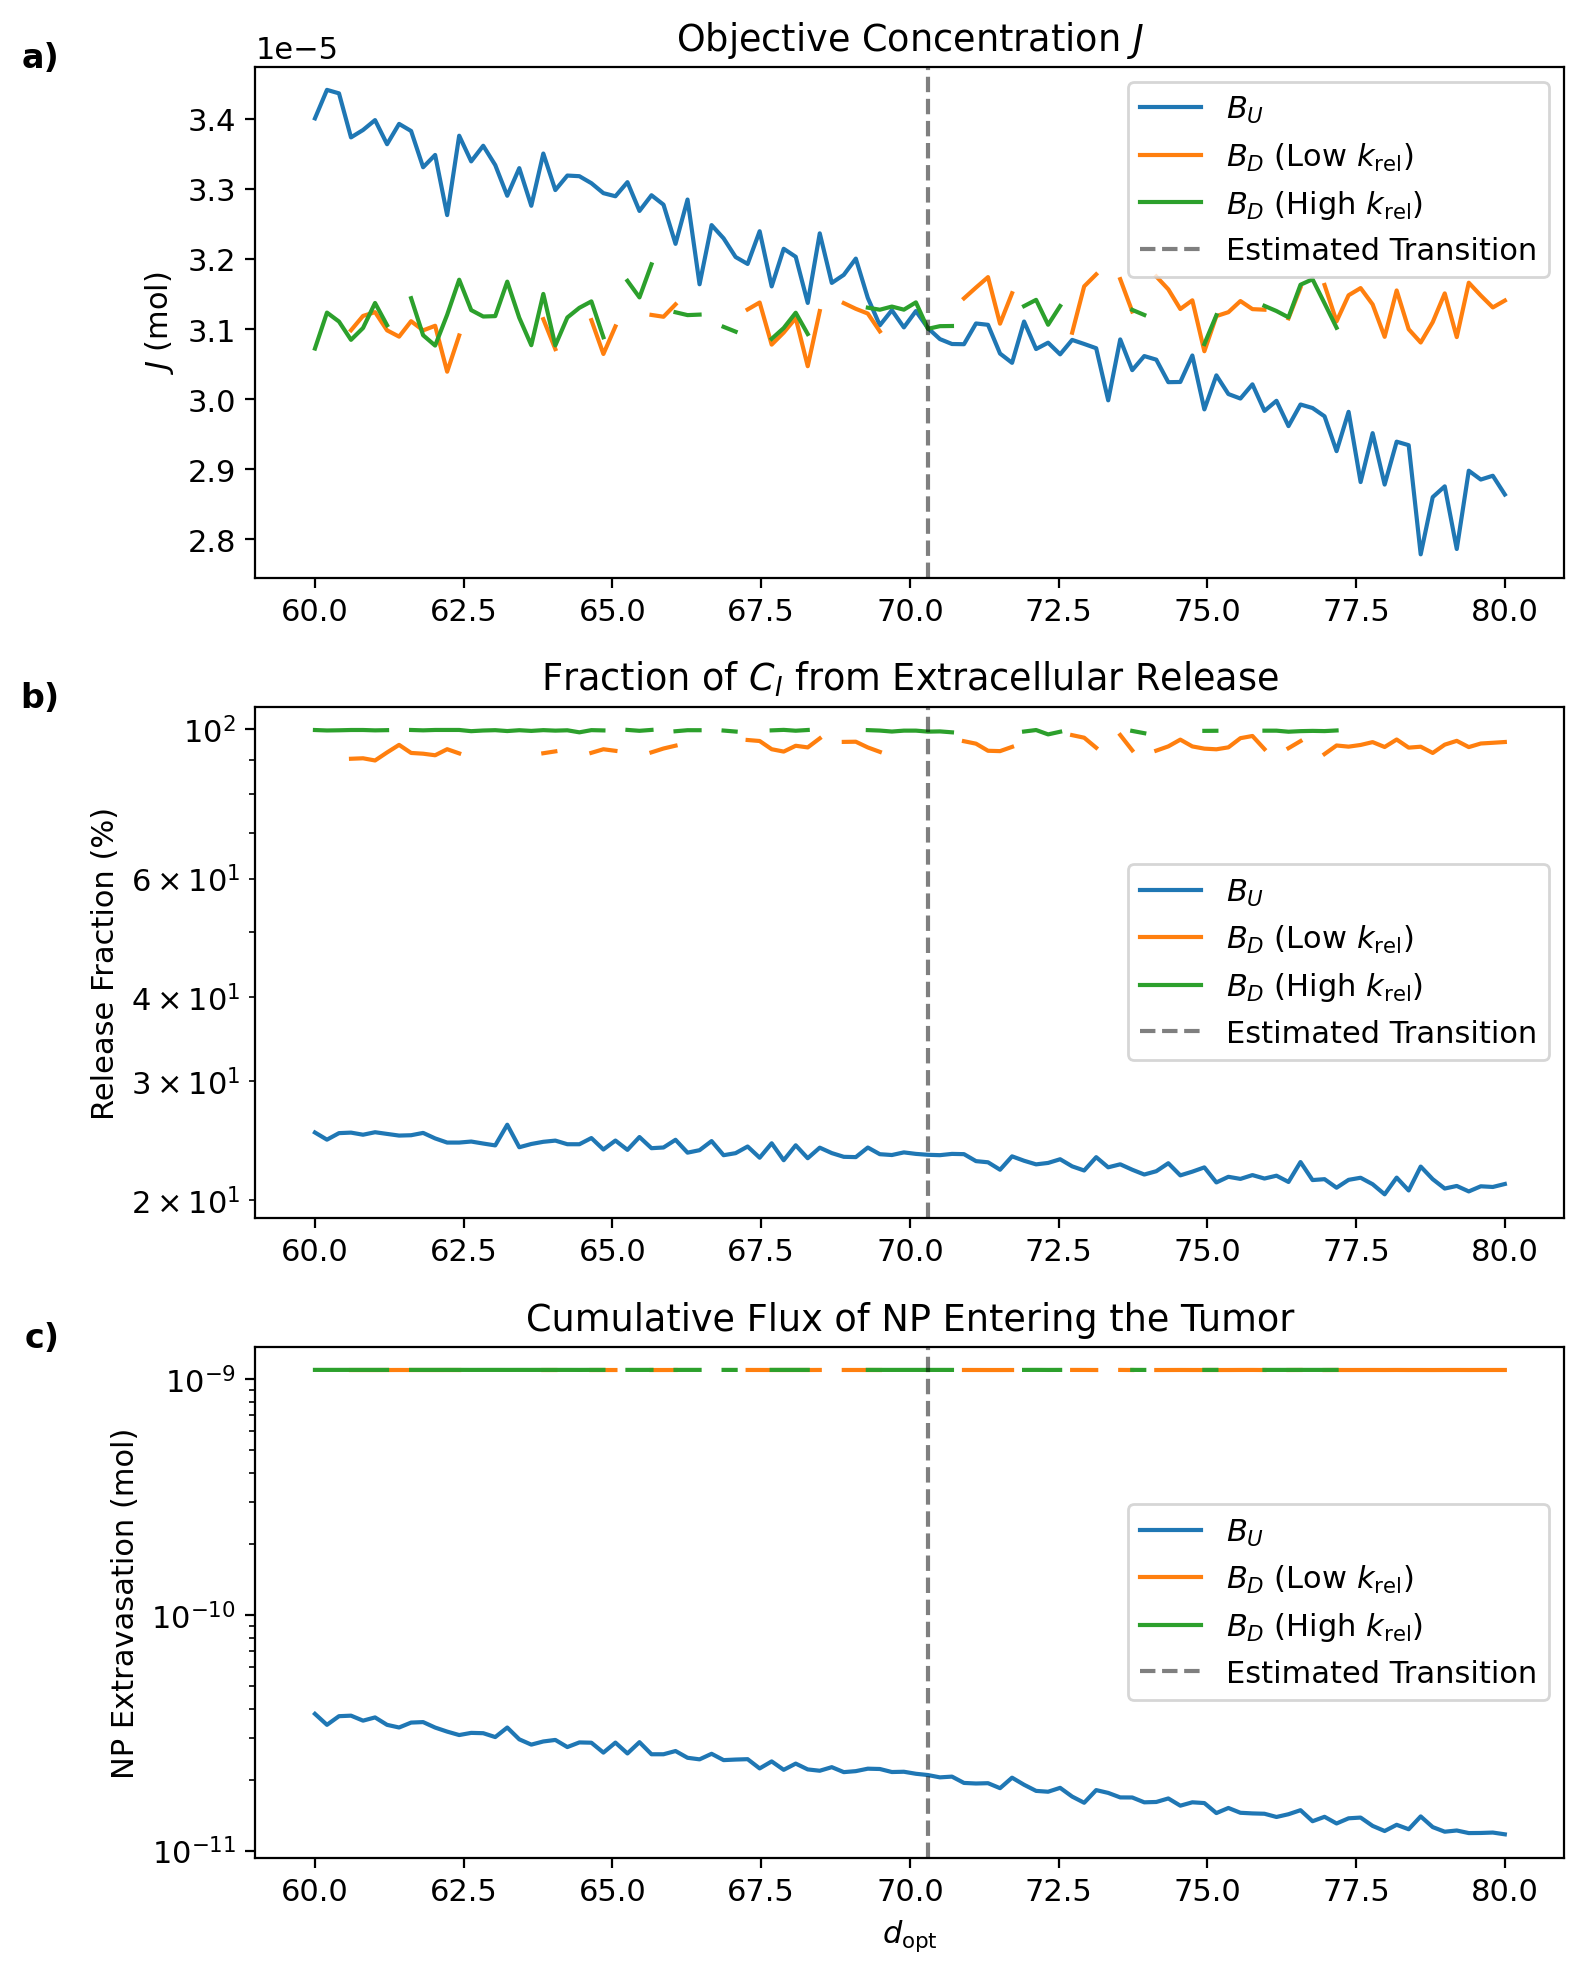

In [54]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))
ax[0].plot(d_opt_branch_vals, high_d_C_I, label= r"$B_U$")
ax[0].plot(d_opt_branch_vals, small_low_k_rel_C_I, label= r"$B_D$ (Low $k_{\mathrm{rel}}$)")
ax[0].plot(d_opt_branch_vals, small_high_k_rel_C_I, label= r"$B_D$ (High $k_{\mathrm{rel}}$)")
ax[0].axvline(crossing, linestyle = "--", c="black", alpha=0.5, label="Estimated Transition")
ax[0].set_ylabel(r"$J $ (mol)")
ax[0].legend()
ax[0].set_title(r"Objective Concentration $J$")
ax[0].text(-0.15, 1.05, "a)", transform=ax[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')


ax[1].plot(d_opt_branch_vals, high_d_ratio, label= r"$B_U$")
ax[1].plot(d_opt_branch_vals, small_low_k_rel_ratio, label= r"$B_D$ (Low $k_{\mathrm{rel}}$)")
ax[1].plot(d_opt_branch_vals, small_high_k_rel_ratio, label= r"$B_D$ (High $k_{\mathrm{rel}}$)")
ax[1].axvline(crossing, linestyle = "--", c="black", alpha=0.5, label="Estimated Transition")
ax[1].set_ylabel("Release Fraction (%)")
ax[1].set_yscale("log")
ax[1].legend()
ax[1].set_title(r"Fraction of $C_I$ from Extracellular Release")
ax[1].text(-0.15, 1.05, "b)", transform=ax[1].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')



ax[2].plot(d_opt_branch_vals, high_d_nanoparticles, label= r"$B_U$")
ax[2].plot(d_opt_branch_vals, small_low_k_rel_nanoparticles, label= r"$B_D$ (Low $k_{\mathrm{rel}}$)")
ax[2].plot(d_opt_branch_vals, small_high_k_rel_nanoparticles, label= r"$B_D$ (High $k_{\mathrm{rel}}$)")
ax[2].axvline(crossing, linestyle = "--", c="black", alpha=0.5, label="Estimated Transition")
ax[2].set_ylabel("NP Extravasation (mol)")
ax[2].set_yscale("log")
ax[2].legend()
ax[2].set_title("Cumulative Flux of NP Entering the Tumor")
ax[2].text(-0.15, 1.05, "c)", transform=ax[2].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')


ax[2].set_xlabel(r"$d_\mathrm{opt}$")

fig.tight_layout()